In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

from scipy.optimize import fsolve

import math
import random

import h5py

### FILE LOCATION

In [2]:
filename = "../DATA/backgrounds/bbaa.h5"

In [3]:
with h5py.File(filename, "r") as f:
    
    # the file has 4 sub-groups inside
    print(" ### Each file should have 11 groups inside: ### \n")
    print("Groups: \n %s \n" % f.keys())

 ### Each file should have 11 groups inside: ### 

Groups: 
 <KeysViewHDF5 ['MET_phi', 'MET_pt', 'btag_eta', 'btag_phi', 'btag_pt', 'jet_eta', 'jet_phi', 'jet_pt', 'photon_eta', 'photon_phi', 'photon_pt']> 



### HIGH LEVEL FEATURES

In [4]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""
    
    phi1 = p1[:,2]
    phi2 = p2[:,2]
    
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""
    
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    
    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    
    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)
    
    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def inv_mass_4vec(px, py, pz, E):
    """invariant mass (massless particles approx). 
    But for 4 vectors"""
    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    phi2 = p2[:,2]
    
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]
    
    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)
    
    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:] 
    
    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)
    
    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )



def higgs_four_vector(p1, p2):
    """
    reconstruct the four vector of the mother particle (assuming it decays to p1 and p2)
    """
    pt1, eta1, phi1 = p1.T
    pt2, eta2, phi2 = p2.T

    px = pt1*np.cos(phi1) + pt2*np.cos(phi2)
    py = pt1*np.sin(phi1) + pt2*np.sin(phi2)
    pz = pt1*np.sinh(eta1) + pt2*np.sinh(eta2)
    E  = pt1*np.cosh(eta1) + pt2*np.cosh(eta2)

    return px, py, pz, E

# ONLY THE ALREADY APPLIED 1st SELECTION CUTS

#### Signal point-1

In [5]:
filename = "../DATA/signal/point1.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_S1 = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_S1 = np.array( [sum(dat) for dat in photon_pt] )

pho1_S1 = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_S1 = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_S1 = [len(dat) for dat in jet_pt]
jet_sumpt_S1 = [sum(dat) for dat in jet_pt]


b_n_S1 = [len(dat) for dat in btag_pt]
b_sumpt_S1 = [sum(dat) for dat in btag_pt]

b1_S1 = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_S1 = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_S1 = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (191677,)
 pho1_S1.shape:  (191677, 3)


In [6]:
initial_evs = 191677
events_ok = 191677

cross_basic_cuts_fb = 0.02659216426864612 # fb

In [7]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.02659216426864612 [fb]
Events expected:  79.77649280593836     for L= 3000  [fb-1]


#### bbaa

In [199]:
filename = "../DATA/backgrounds/bbaa.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_bbaa = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_bbaa = np.array( [sum(dat) for dat in photon_pt] )

pho1_bbaa = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_bbaa = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_bbaa = [len(dat) for dat in jet_pt]
jet_sumpt_bbaa = [sum(dat) for dat in jet_pt]


b_n_bbaa = [len(dat) for dat in btag_pt]
b_sumpt_bbaa = [sum(dat) for dat in btag_pt]

b1_bbaa = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_bbaa = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_bbaa = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_bbaa.shape: ", pho1_bbaa.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (380952,)
 pho1_bbaa.shape:  (380952, 3)


In [200]:
initial_evs = 380952
events_ok = 380952

cross_basic_cuts_fb = 2.171428463266681 # fb

In [201]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  2.171428463266681 [fb]
Events expected:  6514.285389800043     for L= 3000  [fb-1]


#### bbaj (with FAKES)

In [220]:
filename = "../DATA/backgrounds/bbaj_wFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_bbaj = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_bbaj = np.array( [sum(dat) for dat in photon_pt] )

pho1_bbaj = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_bbaj = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_bbaj = [len(dat) for dat in jet_pt]
jet_sumpt_bbaj = [sum(dat) for dat in jet_pt]


b_n_bbaj = [len(dat) for dat in btag_pt]
b_sumpt_bbaj = [sum(dat) for dat in btag_pt]

b1_bbaj = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_bbaj = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_bbaj = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_bbaj.shape: ", pho1_bbaj.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2802,)
 pho1_bbaj.shape:  (2802, 3)


In [221]:
initial_evs = 2802
events_ok = 2802

cross_basic_cuts_fb = 19.386077717379234 # fb

In [222]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  19.386077717379234 [fb]
Events expected:  58158.2331521377     for L= 3000  [fb-1]


#### bbaj (NO FAKES)

In [217]:
filename = "../DATA/backgrounds/bbaj_noFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_bbaj_noFAKES = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_bbaj_noFAKES = np.array( [sum(dat) for dat in photon_pt] )

pho1_bbaj_noFAKES = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_bbaj_noFAKES = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_bbaj_noFAKES = [len(dat) for dat in jet_pt]
jet_sumpt_bbaj_noFAKES = [sum(dat) for dat in jet_pt]


b_n_bbaj_noFAKES = [len(dat) for dat in btag_pt]
b_sumpt_bbaj_noFAKES = [sum(dat) for dat in btag_pt]

b1_bbaj_noFAKES = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_bbaj_noFAKES = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_bbaj_noFAKES = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_bbaj_noFAKES.shape: ", pho1_bbaj_noFAKES.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2428,)
 pho1_bbaj_noFAKES.shape:  (2428, 3)


In [218]:
initial_evs = 2428
events_ok = 2428

cross_basic_cuts_fb = 16.790270624904363 # fb

In [219]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  16.790270624904363 [fb]
Events expected:  50370.81187471309     for L= 3000  [fb-1]


#### tth

In [205]:
filename = "../DATA/backgrounds/tth.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_tth = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_tth = np.array( [sum(dat) for dat in photon_pt] )

pho1_tth = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_tth = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_tth = [len(dat) for dat in jet_pt]
jet_sumpt_tth = [sum(dat) for dat in jet_pt]


b_n_tth = [len(dat) for dat in btag_pt]
b_sumpt_tth = [sum(dat) for dat in btag_pt]

b1_tth = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_tth = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_tth = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_tth.shape: ", pho1_tth.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (606082,)
 pho1_tth.shape:  (606082, 3)


In [206]:
initial_evs = 606082
events_ok = 606082

cross_basic_cuts_fb = 0.033768365117857184 # fb

In [207]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.033768365117857184 [fb]
Events expected:  101.30509535357155     for L= 3000  [fb-1]


#### zh

In [208]:
filename = "../DATA/backgrounds/zh.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# info separated as arrays
pho_n_zh = np.array( [len(dat) for dat in photon_pt] )
pho_sumpt_zh = np.array( [sum(dat) for dat in photon_pt] )

pho1_zh = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])
pho2_zh = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(photon_pt, photon_eta, photon_phi) if len(pt) > 0 ])


jet_n_zh = [len(dat) for dat in jet_pt]
jet_sumpt_zh = [sum(dat) for dat in jet_pt]


b_n_zh = [len(dat) for dat in btag_pt]
b_sumpt_zh = [sum(dat) for dat in btag_pt]

b1_zh = np.array([ [pt[0], eta[0], phi[0]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])
b2_zh = np.array([ [pt[1], eta[1], phi[1]] for pt, eta, phi in zip(btag_pt, btag_eta, btag_phi) if len(pt) > 0 ])


MET_zh = np.array([ [pt[0], phi[0]] for pt, phi in zip(MET_pt, MET_phi) if len(pt) > 0 ])


print(" pho1_zh.shape: ", pho1_zh.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (83047,)
 pho1_zh.shape:  (83047, 3)


In [209]:
initial_evs = 83047
events_ok = 83047

cross_basic_cuts_fb = 0.006521839124728637 # fb

In [210]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.006521839124728637 [fb]
Events expected:  19.565517374185912     for L= 3000  [fb-1]


In [216]:
print('MAX Only NOb-tagged # jets: ')
print( max( jet_n_bbaa ))
print( max( jet_n_bbaj ))
print( max( jet_n_tth ))
print( max( jet_n_zh ))


print('\nMAX b-tagged + NOb-tagged # jets: ')
print( max( jet_n_bbaa + b_n_bbaa ))
print( max( jet_n_bbaj + b_n_bbaj ))
print( max( jet_n_tth + b_n_tth ))
print( max( jet_n_zh + b_n_zh))

MAX Only NOb-tagged # jets: 
3
3
3
3

MAX b-tagged + NOb-tagged # jets: 
5
4
5
4


### HIGH LEVEL FEATURES

In [5]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""
    
    phi1 = p1[:,2]
    phi2 = p2[:,2]
    
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""
    
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    
    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    
    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)
    
    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def inv_mass_4vec(px, py, pz, E):
    """invariant mass (massless particles approx). 
    But for 4 vectors"""
    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    phi2 = p2[:,2]
    
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]
    
    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)
    
    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:] 
    
    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)
    
    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )



def higgs_four_vector(p1, p2):
    """
    reconstruct the four vector of the mother particle (assuming it decays to p1 and p2)
    """
    pt1, eta1, phi1 = p1.T
    pt2, eta2, phi2 = p2.T

    px = pt1*np.cos(phi1) + pt2*np.cos(phi2)
    py = pt1*np.sin(phi1) + pt2*np.sin(phi2)
    pz = pt1*np.sinh(eta1) + pt2*np.sinh(eta2)
    E  = pt1*np.cosh(eta1) + pt2*np.cosh(eta2)

    return px, py, pz, E

In [9]:
# delta R
dR_pho1_pho2_bbaa = delta_R(pho1_bbaa, pho2_bbaa)
dR_b1_b2_bbaa = delta_R(b1_bbaa, b2_bbaa)

dR_pho1_b1_bbaa = delta_R(pho1_bbaa, b1_bbaa)
dR_pho1_b2_bbaa = delta_R(pho1_bbaa, b2_bbaa)

dR_pho2_b1_bbaa = delta_R(pho2_bbaa, b1_bbaa)
dR_pho2_b2_bbaa = delta_R(pho2_bbaa, b2_bbaa)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaa = pT12(pho1_bbaa, pho2_bbaa)
pT_b1_b2_bbaa = pT12(b1_bbaa, b2_bbaa)

pT_pho1_b1_bbaa = pT12(pho1_bbaa, b1_bbaa)
pT_pho1_b2_bbaa = pT12(pho1_bbaa, b2_bbaa)

pT_pho2_b1_bbaa = pT12(pho2_bbaa, b1_bbaa)
pT_pho2_b2_bbaa = pT12(pho2_bbaa, b2_bbaa)


# invariant mass
m_pho1_pho2_bbaa = inv_mass(pho1_bbaa, pho2_bbaa)
m_b1_b2_bbaa = inv_mass(b1_bbaa, b2_bbaa)

m_pho1_b1_bbaa = inv_mass(pho1_bbaa, b1_bbaa)
m_pho1_b2_bbaa = inv_mass(pho1_bbaa, b2_bbaa)

m_pho2_b1_bbaa = inv_mass(pho2_bbaa, b1_bbaa)
m_pho2_b2_bbaa = inv_mass(pho2_bbaa, b2_bbaa)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaa, b2_bbaa)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaa, pho2_bbaa)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaa = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [10]:
# delta R
dR_pho1_pho2_bbaj = delta_R(pho1_bbaj, pho2_bbaj)
dR_b1_b2_bbaj = delta_R(b1_bbaj, b2_bbaj)

dR_pho1_b1_bbaj = delta_R(pho1_bbaj, b1_bbaj)
dR_pho1_b2_bbaj = delta_R(pho1_bbaj, b2_bbaj)

dR_pho2_b1_bbaj = delta_R(pho2_bbaj, b1_bbaj)
dR_pho2_b2_bbaj = delta_R(pho2_bbaj, b2_bbaj)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaj = pT12(pho1_bbaj, pho2_bbaj)
pT_b1_b2_bbaj = pT12(b1_bbaj, b2_bbaj)

pT_pho1_b1_bbaj = pT12(pho1_bbaj, b1_bbaj)
pT_pho1_b2_bbaj = pT12(pho1_bbaj, b2_bbaj)

pT_pho2_b1_bbaj = pT12(pho2_bbaj, b1_bbaj)
pT_pho2_b2_bbaj = pT12(pho2_bbaj, b2_bbaj)


# invariant mass
m_pho1_pho2_bbaj = inv_mass(pho1_bbaj, pho2_bbaj)
m_b1_b2_bbaj = inv_mass(b1_bbaj, b2_bbaj)

m_pho1_b1_bbaj = inv_mass(pho1_bbaj, b1_bbaj)
m_pho1_b2_bbaj = inv_mass(pho1_bbaj, b2_bbaj)

m_pho2_b1_bbaj = inv_mass(pho2_bbaj, b1_bbaj)
m_pho2_b2_bbaj = inv_mass(pho2_bbaj, b2_bbaj)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaj, b2_bbaj)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaj, pho2_bbaj)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaj = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [11]:
# delta R
dR_pho1_pho2_tth = delta_R(pho1_tth, pho2_tth)
dR_b1_b2_tth = delta_R(b1_tth, b2_tth)

dR_pho1_b1_tth = delta_R(pho1_tth, b1_tth)
dR_pho1_b2_tth = delta_R(pho1_tth, b2_tth)

dR_pho2_b1_tth = delta_R(pho2_tth, b1_tth)
dR_pho2_b2_tth = delta_R(pho2_tth, b2_tth)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_tth = pT12(pho1_tth, pho2_tth)
pT_b1_b2_tth = pT12(b1_tth, b2_tth)

pT_pho1_b1_tth = pT12(pho1_tth, b1_tth)
pT_pho1_b2_tth = pT12(pho1_tth, b2_tth)

pT_pho2_b1_tth = pT12(pho2_tth, b1_tth)
pT_pho2_b2_tth = pT12(pho2_tth, b2_tth)


# invariant mass
m_pho1_pho2_tth = inv_mass(pho1_tth, pho2_tth)
m_b1_b2_tth = inv_mass(b1_tth, b2_tth)

m_pho1_b1_tth = inv_mass(pho1_tth, b1_tth)
m_pho1_b2_tth = inv_mass(pho1_tth, b2_tth)

m_pho2_b1_tth = inv_mass(pho2_tth, b1_tth)
m_pho2_b2_tth = inv_mass(pho2_tth, b2_tth)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_tth, b2_tth)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_tth, pho2_tth)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_tth = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [12]:
# delta R
dR_pho1_pho2_zh = delta_R(pho1_zh, pho2_zh)
dR_b1_b2_zh = delta_R(b1_zh, b2_zh)

dR_pho1_b1_zh = delta_R(pho1_zh, b1_zh)
dR_pho1_b2_zh = delta_R(pho1_zh, b2_zh)

dR_pho2_b1_zh = delta_R(pho2_zh, b1_zh)
dR_pho2_b2_zh = delta_R(pho2_zh, b2_zh)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_zh = pT12(pho1_zh, pho2_zh)
pT_b1_b2_zh = pT12(b1_zh, b2_zh)

pT_pho1_b1_zh = pT12(pho1_zh, b1_zh)
pT_pho1_b2_zh = pT12(pho1_zh, b2_zh)

pT_pho2_b1_zh = pT12(pho2_zh, b1_zh)
pT_pho2_b2_zh = pT12(pho2_zh, b2_zh)


# invariant mass
m_pho1_pho2_zh = inv_mass(pho1_zh, pho2_zh)
m_b1_b2_zh = inv_mass(b1_zh, b2_zh)

m_pho1_b1_zh = inv_mass(pho1_zh, b1_zh)
m_pho1_b2_zh = inv_mass(pho1_zh, b2_zh)

m_pho2_b1_zh = inv_mass(pho2_zh, b1_zh)
m_pho2_b2_zh = inv_mass(pho2_zh, b2_zh)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_zh, b2_zh)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_zh, pho2_zh)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_zh = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

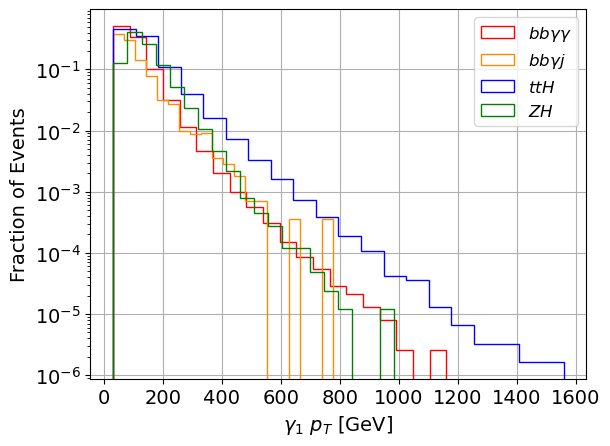

In [71]:
Nbins=20

weights = np.ones_like(pho1_bbaa[:,0])/float(len(pho1_bbaa[:,0]))
plt.hist(pho1_bbaa[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho1_bbaj[:,0])/float(len(pho1_bbaj[:,0]))
plt.hist(pho1_bbaj[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho1_tth[:,0])/float(len(pho1_tth[:,0]))
plt.hist(pho1_tth[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='blue', histtype='step', label="$ttH$")
weights = np.ones_like(pho1_zh[:,0])/float(len(pho1_zh[:,0]))
plt.hist(pho1_zh[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='green', histtype='step', label="$ZH$")

plt.grid()  # Add grid lines
# plt.title(title,fontsize=14)  # Titles etc
plt.xlabel("$\gamma_1$ $p_T$ [GeV]",fontsize=14)
plt.ylabel("Fraction of Events",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper right',fontsize=12)
plt.show()

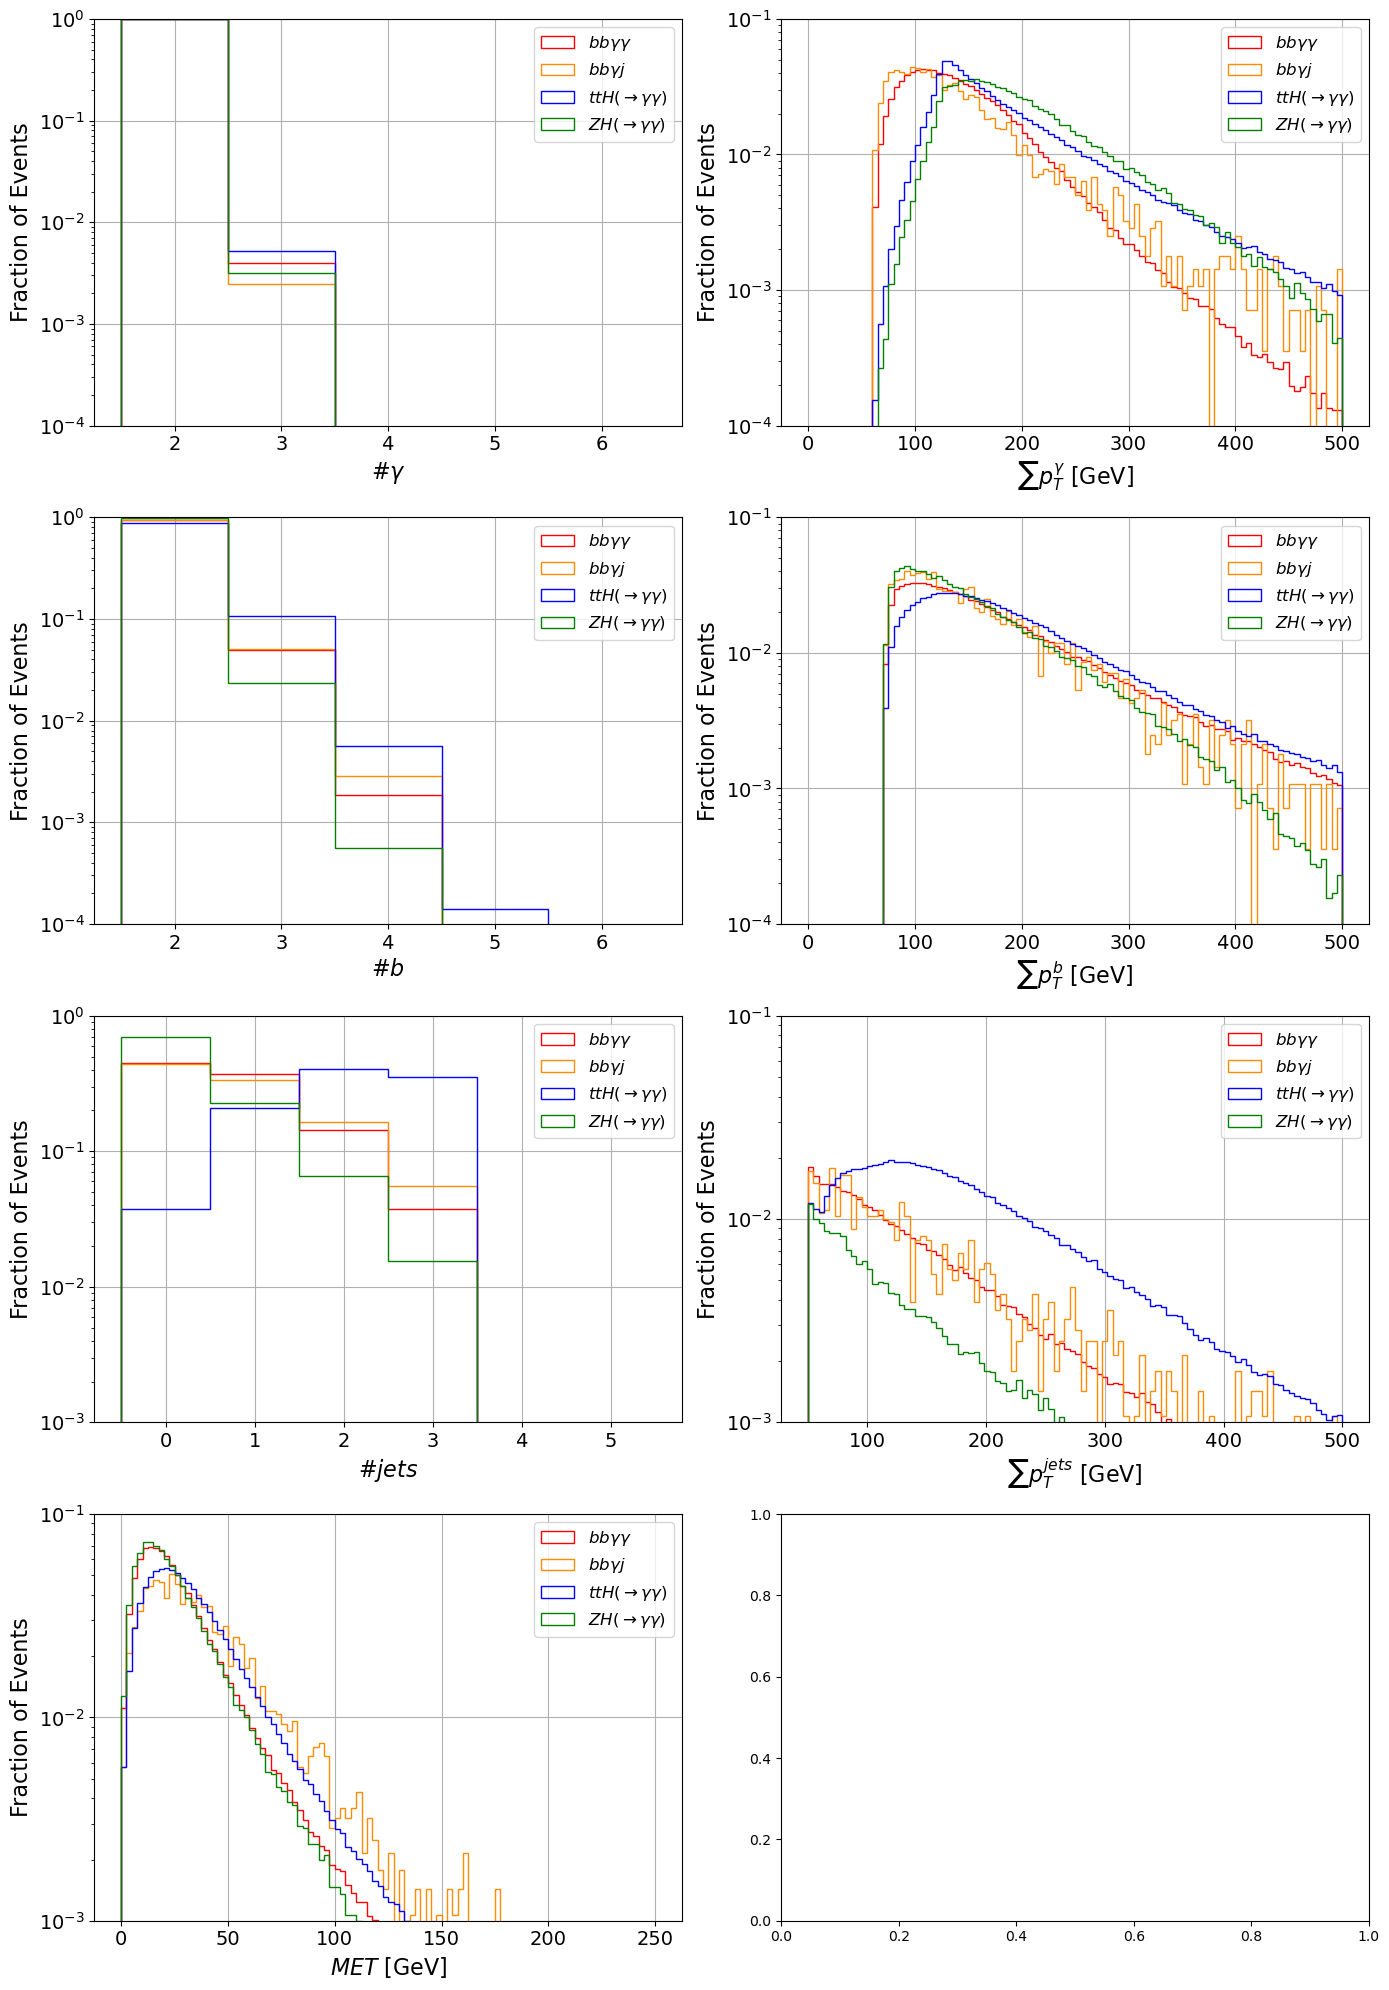

In [70]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# N gamma
ax = axes[0]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(pho_n_bbaa)/float(len(pho_n_bbaa))
ax.hist(pho_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_n_bbaj)/float(len(pho_n_bbaj))
ax.hist(pho_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_n_tth)/float(len(pho_n_tth))
ax.hist(pho_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_n_zh)/float(len(pho_n_zh))
ax.hist(pho_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$\gamma$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT gamma
ax = axes[1]
Nbins= 100
rang = [0,500]

weights = np.ones_like(pho_sumpt_bbaa)/float(len(pho_sumpt_bbaa))
ax.hist(pho_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_sumpt_bbaj)/float(len(pho_sumpt_bbaj))
ax.hist(pho_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_sumpt_tth)/float(len(pho_sumpt_tth))
ax.hist(pho_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_sumpt_zh)/float(len(pho_sumpt_zh))
ax.hist(pho_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# N bs
ax = axes[2]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(b_n_bbaa)/float(len(b_n_bbaa))
ax.hist(b_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_n_bbaj)/float(len(b_n_bbaj))
ax.hist(b_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_n_tth)/float(len(b_n_tth))
ax.hist(b_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_n_zh)/float(len(b_n_zh))
ax.hist(b_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$b$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT bs
ax = axes[3]
Nbins= 100
rang = [0,500]

weights = np.ones_like(b_sumpt_bbaa)/float(len(b_sumpt_bbaa))
ax.hist(b_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_sumpt_bbaj)/float(len(b_sumpt_bbaj))
ax.hist(b_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_sumpt_tth)/float(len(b_sumpt_tth))
ax.hist(b_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_sumpt_zh)/float(len(b_sumpt_zh))
ax.hist(b_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{b}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# N jets
ax = axes[4]
Nbins= 6
rang = [-0.5,5.5]

weights = np.ones_like(jet_n_bbaa)/float(len(jet_n_bbaa))
ax.hist(jet_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_n_bbaj)/float(len(jet_n_bbaj))
ax.hist(jet_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_n_tth)/float(len(jet_n_tth))
ax.hist(jet_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_n_zh)/float(len(jet_n_zh))
ax.hist(jet_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("#$jets$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT jets
ax = axes[5]
Nbins= 100
rang = [50,500]

weights = np.ones_like(jet_sumpt_bbaa)/float(len(jet_sumpt_bbaa))
ax.hist(jet_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_sumpt_bbaj)/float(len(jet_sumpt_bbaj))
ax.hist(jet_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_sumpt_tth)/float(len(jet_sumpt_tth))
ax.hist(jet_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_sumpt_zh)/float(len(jet_sumpt_zh))
ax.hist(jet_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$\sum p_T^{jets}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# MET
ax = axes[6]
Nbins= 100
rang = [0,200]

weights = np.ones_like(MET_bbaa[:,0])/float(len(MET_bbaa[:,0]))
ax.hist(MET_bbaa[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(MET_bbaj[:,0])/float(len(MET_bbaj[:,0]))
ax.hist(MET_bbaj[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(MET_tth[:,0])/float(len(MET_tth[:,0]))
ax.hist(MET_tth[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(MET_zh[:,0])/float(len(MET_zh[:,0]))
ax.hist(MET_zh[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$MET$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

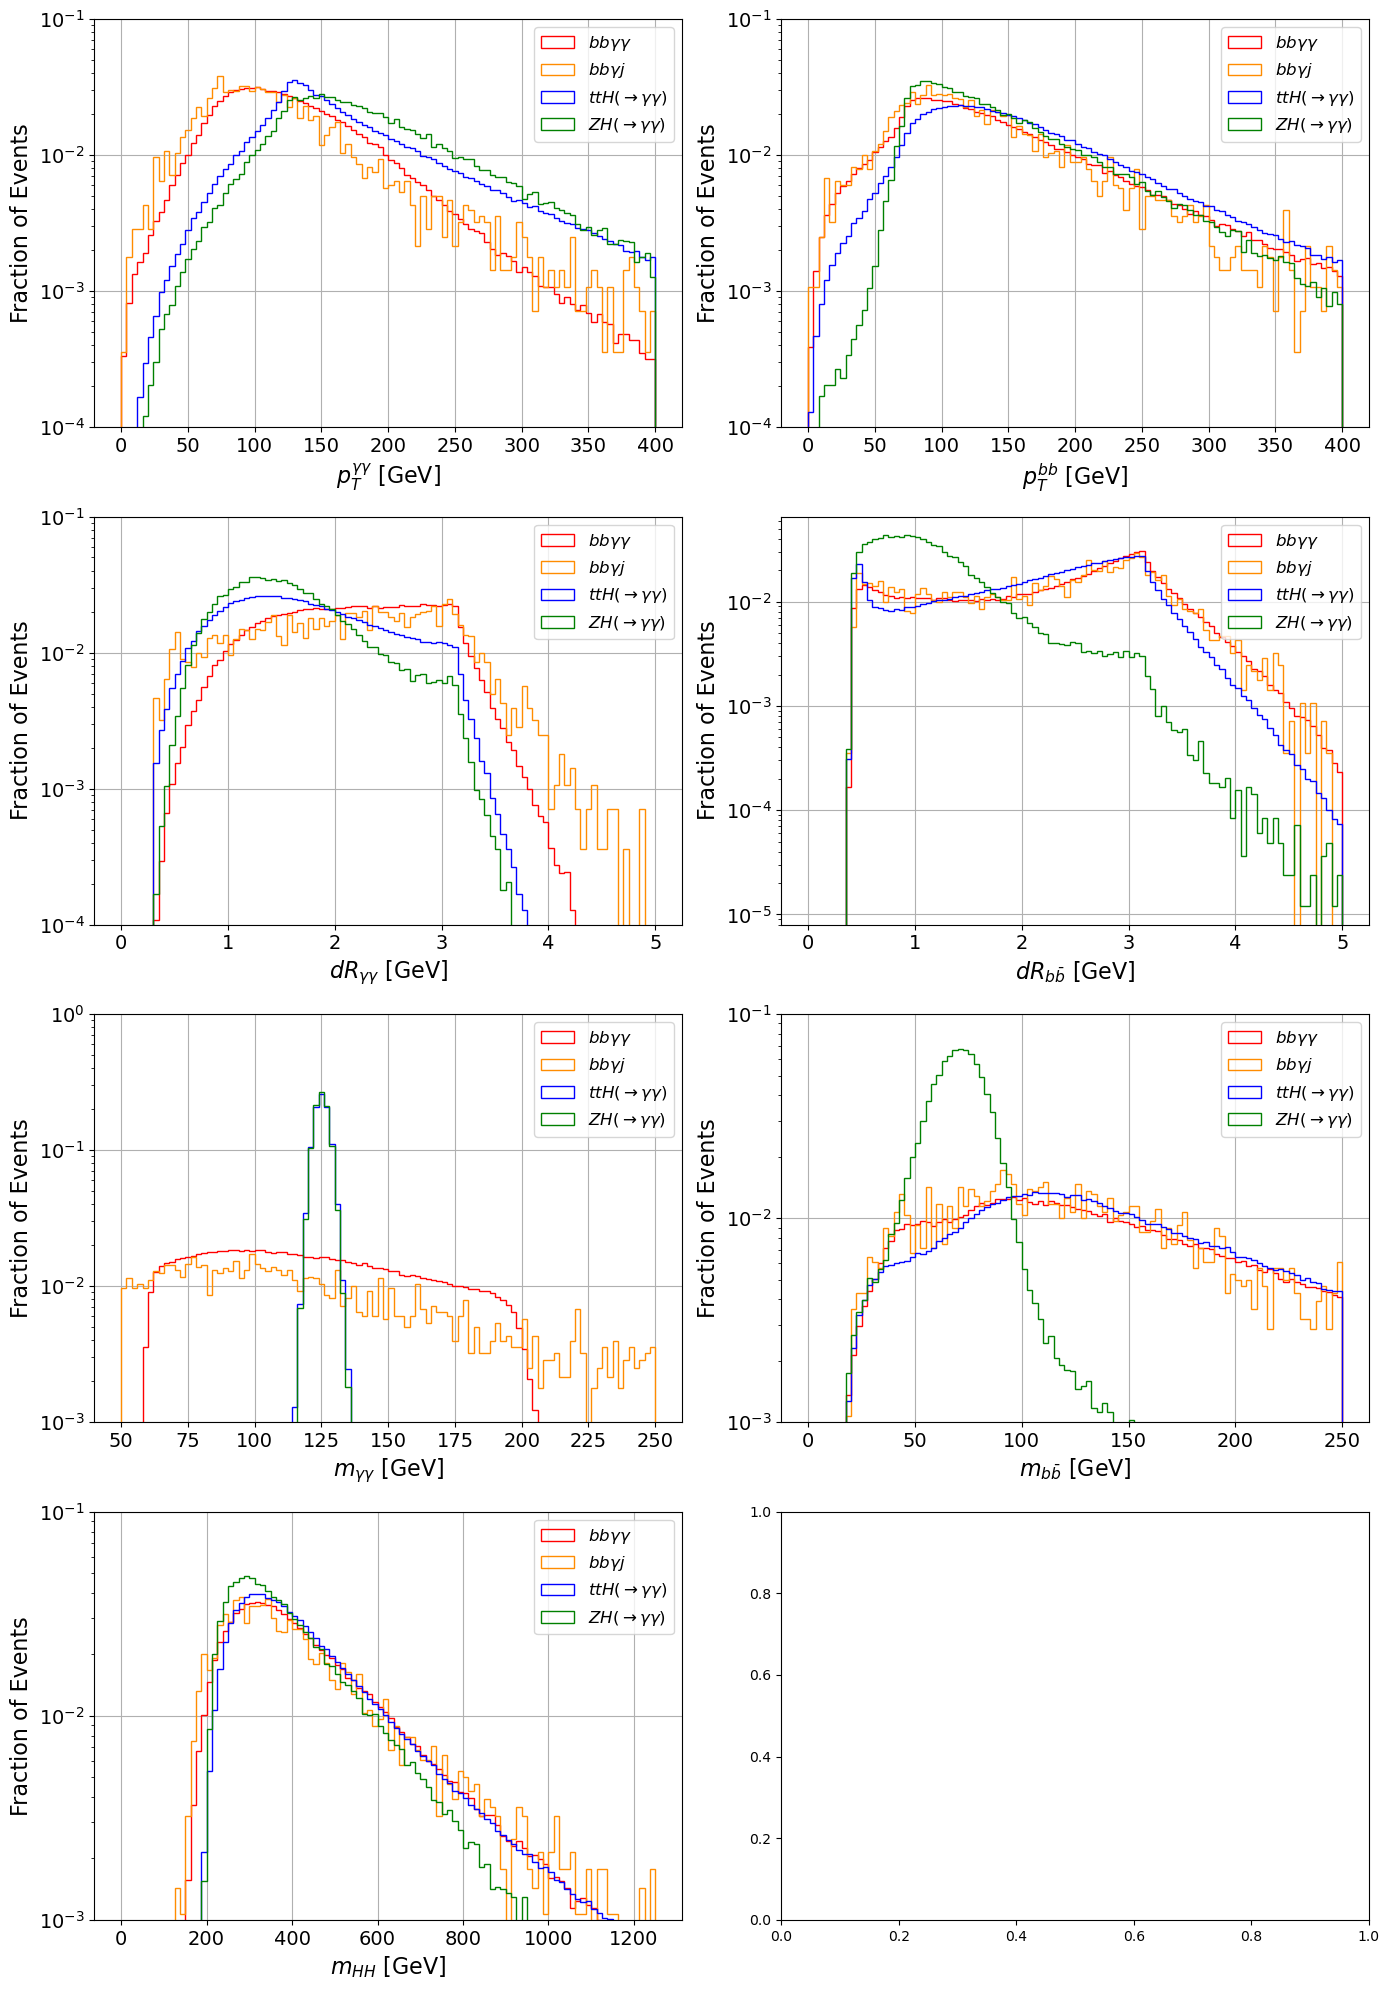

In [59]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# pT_pp
ax = axes[0]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_pho1_pho2_bbaa)/float(len(pT_pho1_pho2_bbaa))
ax.hist(pT_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_pho1_pho2_bbaj)/float(len(pT_pho1_pho2_bbaj))
ax.hist(pT_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_pho1_pho2_tth)/float(len(pT_pho1_pho2_tth))
ax.hist(pT_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_pho1_pho2_zh)/float(len(pT_pho1_pho2_zh))
ax.hist(pT_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# pT_bb
ax = axes[1]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_b1_b2_bbaa)/float(len(pT_b1_b2_bbaa))
ax.hist(pT_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_b1_b2_bbaj)/float(len(pT_b1_b2_bbaj))
ax.hist(pT_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_b1_b2_tth)/float(len(pT_b1_b2_tth))
ax.hist(pT_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_b1_b2_zh)/float(len(pT_b1_b2_zh))
ax.hist(pT_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{bb}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_pp
ax = axes[2]
Nbins= 100
rang = [0,5]

weights = np.ones_like(dR_pho1_pho2_bbaa)/float(len(dR_pho1_pho2_bbaa))
ax.hist(dR_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_pho1_pho2_bbaj)/float(len(dR_pho1_pho2_bbaj))
ax.hist(dR_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_pho1_pho2_tth)/float(len(dR_pho1_pho2_tth))
ax.hist(dR_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_pho1_pho2_zh)/float(len(dR_pho1_pho2_zh))
ax.hist(dR_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$dR_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_bb
ax = axes[3]
Nbins= 100
rang = [0,5]

weights = np.ones_like(dR_b1_b2_bbaa)/float(len(dR_b1_b2_bbaa))
ax.hist(dR_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_b1_b2_bbaj)/float(len(dR_b1_b2_bbaj))
ax.hist(dR_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_b1_b2_tth)/float(len(dR_b1_b2_tth))
ax.hist(dR_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_b1_b2_zh)/float(len(dR_b1_b2_zh))
ax.hist(dR_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
# ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$dR_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# m_pp
ax = axes[4]
Nbins= 100
rang = [50,250]

weights = np.ones_like(m_pho1_pho2_bbaa)/float(len(m_pho1_pho2_bbaa))
ax.hist(m_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_pho1_pho2_bbaj)/float(len(m_pho1_pho2_bbaj))
ax.hist(m_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_pho1_pho2_tth)/float(len(m_pho1_pho2_tth))
ax.hist(m_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_pho1_pho2_zh)/float(len(m_pho1_pho2_zh))
ax.hist(m_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("$m_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_bb
ax = axes[5]
Nbins= 100
rang = [0,250]

weights = np.ones_like(m_b1_b2_bbaa)/float(len(m_b1_b2_bbaa))
ax.hist(m_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_b1_b2_bbaj)/float(len(m_b1_b2_bbaj))
ax.hist(m_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_b1_b2_tth)/float(len(m_b1_b2_tth))
ax.hist(m_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_b1_b2_zh)/float(len(m_b1_b2_zh))
ax.hist(m_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$m_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_HH
ax = axes[6]
Nbins= 100
rang = [0,1250]

weights = np.ones_like(m_HH_bbaa)/float(len(m_HH_bbaa))
ax.hist(m_HH_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_HH_bbaj)/float(len(m_HH_bbaj))
ax.hist(m_HH_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_HH_tth)/float(len(m_HH_tth))
ax.hist(m_HH_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_HH_zh)/float(len(m_HH_zh))
ax.hist(m_HH_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$m_{HH}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

#  MORE CUTS (no mbb and mphopho cut)

In [5]:
import itertools

MH = 125.0

# TRY ALL POSSIBLE COMBINATIONS ADN KEEP THE ONE THAT IS CLOSEST TO THE HIGGS MASS
def best_pair_mass(particles):
    """
    particles: array (N,3) with [pt, eta, phi]
    returns: indices (i,j), mass
    """
    best = None
    best_dm = 1e9

    for i, j in itertools.combinations(range(len(particles)), 2):
        m = inv_mass(particles[i:i+1], particles[j:j+1])[0]
        dm = abs(m - MH)
        if dm < best_dm:
            best_dm = dm
            best = (i, j, m)

    return best  # (i, j, m)



def pass_HH_extra_cuts(photons, bjets, jets):
    """
    photons, bjets, jets: arrays with [pt, eta, phi]
    """

    # --- need at least 2 and 2 ---
    if len(photons) < 2 or len(bjets) < 2:
        return False, None, None, None, None

    # --- choose best Higgs candidates ---
    ip, jp, m_phopho = best_pair_mass(photons)
    ib, jb, m_bb = best_pair_mass(bjets)

    pho1, pho2 = photons[ip], photons[jp]
    b1, b2 = bjets[ib], bjets[jb]

    # # --- mass windows ---
    # if not (122 < m_phopho < 128):
    #     return False, None, None, None, None
    # if not (80 < m_bb < 130):
    #     return False, None, None, None, None

    # --- ΔR cuts ---
    if not (0.4 < delta_R(pho1[None,:], pho2[None,:])[0] < 2.0):
        return False, None, None, None, None
    if not (0.4 < delta_R(b1[None,:], b2[None,:])[0] < 2.0):
        return False, None, None, None, None

    # --- pT of Higgs candidates ---
    if pT12(pho1[None,:], pho2[None,:])[0] < 80:
        return False, None, None, None, None
    if pT12(b1[None,:], b2[None,:])[0] < 80:
        return False, None, None, None, None

    # --- ΔR(γ, j) isolation ---
    for phot in [pho1, pho2]:
        for j in jets:
            if delta_R(phot[None,:], j[None,:])[0] < 0.4:
                return False, None, None, None, None

    return True, ip, jp, ib, jb

#### SM Higgs (double production)

In [11]:
BPnum = 0

filename = "../DATA/SMhiggs/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (46194,)
 pho1_S1.shape:  (35960, 3)


In [12]:
initial_evs = 46194
events_ok = 35960

cross_basic_cuts_fb = 0.01225520302210844 # fb

In [13]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.009540137261874257 [fb]
Events expected:  28.62041178562277     for L= 3000  [fb-1]


In [14]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/SMhiggs/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal point-1

In [42]:
filename = "../DATA/signal/point1.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (191677,)
 pho1_S1.shape:  (153551, 3)


In [11]:
initial_evs = 191677
events_ok = 153551

cross_basic_cuts_fb = 0.02659216426864612 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.021302782366245717 [fb]
Events expected:  63.90834709873715     for L= 3000  [fb-1]


In [43]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/point1_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP28

In [7]:
BPnum = 28

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9033,)
 pho1_S1.shape:  (7300, 3)


In [8]:
initial_evs = 9033
events_ok = 7300

cross_basic_cuts_fb = 0.024989242808791227 # fb

In [9]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.020195004151907003 [fb]
Events expected:  60.585012455721014     for L= 3000  [fb-1]


In [14]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP62

In [11]:
BPnum = 62

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9919,)
 pho1_S1.shape:  (7736, 3)


In [12]:
initial_evs = 9919
events_ok = 7736

cross_basic_cuts_fb = 0.019497673348043552 # fb

In [13]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.015206573346150309 [fb]
Events expected:  45.61972003845093     for L= 3000  [fb-1]


In [14]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP63

In [15]:
BPnum = 63

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (10295,)
 pho1_S1.shape:  (8062, 3)


In [16]:
initial_evs = 10295
events_ok = 8062

cross_basic_cuts_fb = 0.023476322585467904 # fb

In [17]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.018384275151436837 [fb]
Events expected:  55.15282545431051     for L= 3000  [fb-1]


In [18]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP219

In [19]:
BPnum = 219

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9757,)
 pho1_S1.shape:  (7590, 3)


In [20]:
initial_evs = 9757
events_ok = 7590

cross_basic_cuts_fb = 0.021331297451083257 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.01659368121899374 [fb]
Events expected:  49.78104365698122     for L= 3000  [fb-1]


In [22]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP220

In [23]:
BPnum = 220

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (14460,)
 pho1_S1.shape:  (11096, 3)


In [24]:
initial_evs = 14460
events_ok = 11096

cross_basic_cuts_fb = 0.019442109908935964 # fb

In [25]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.014919063039388206 [fb]
Events expected:  44.75718911816462     for L= 3000  [fb-1]


In [26]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP279 (la plata team) (NOT DONE)

In [18]:
BPnum = 279

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (10103,)
 pho1_S1.shape:  (7827, 3)


In [19]:
initial_evs = 10103
events_ok = 7827

cross_basic_cuts_fb = 0.02251592207491453 # fb

In [20]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.017443543707844802 [fb]
Events expected:  52.33063112353441     for L= 3000  [fb-1]


In [21]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP315 (la plata team) (NOT DONE)

In [22]:
BPnum = 315

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (13003,)
 pho1_S1.shape:  (10374, 3)


In [23]:
initial_evs = 13003
events_ok = 10374

cross_basic_cuts_fb = 0.30153106424074455 # fb

In [24]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.24056627397012106 [fb]
Events expected:  721.6988219103632     for L= 3000  [fb-1]


In [25]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP455 (la plata team) (NOT DONE)

In [26]:
BPnum = 455

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (11129,)
 pho1_S1.shape:  (8956, 3)


In [27]:
initial_evs = 11129
events_ok = 8956

cross_basic_cuts_fb = 0.023051290889386688 # fb

In [28]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.018550396370325024 [fb]
Events expected:  55.651189110975075     for L= 3000  [fb-1]


In [29]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP502 (la plata team)

In [7]:
BPnum = 502

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (11160,)
 pho1_S1.shape:  (8914, 3)


In [8]:
initial_evs = 11160
events_ok = 8914

cross_basic_cuts_fb = 0.022475360322298323 # fb

In [9]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.017952093361376997 [fb]
Events expected:  53.85628008413099     for L= 3000  [fb-1]


In [10]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP563 (la plata team) (NOT DONE)

In [34]:
BPnum = 563

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (12164,)
 pho1_S1.shape:  (9884, 3)


In [35]:
initial_evs = 12164
events_ok = 9884

cross_basic_cuts_fb = 0.03577062977431175 # fb

In [36]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.029065842213852135 [fb]
Events expected:  87.19752664155641     for L= 3000  [fb-1]


In [37]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP586

In [27]:
BPnum = 586

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (14546,)
 pho1_S1.shape:  (11057, 3)


In [28]:
initial_evs = 14546
events_ok = 11057

cross_basic_cuts_fb = 0.018995021924002615 # fb

In [29]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.01443888061416863 [fb]
Events expected:  43.31664184250589     for L= 3000  [fb-1]


In [30]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP626

In [11]:
BPnum = 626

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9982,)
 pho1_S1.shape:  (7918, 3)


In [12]:
initial_evs = 9982
events_ok = 7918

cross_basic_cuts_fb = 0.019233311608190386 # fb

In [13]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.015256397647129983 [fb]
Events expected:  45.769192941389946     for L= 3000  [fb-1]


In [14]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP635

In [31]:
BPnum = 635

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9597,)
 pho1_S1.shape:  (7258, 3)


In [32]:
initial_evs = 9597
events_ok = 7258

cross_basic_cuts_fb = 0.016901333741559874 # fb

In [33]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.012782106939277019 [fb]
Events expected:  38.34632081783106     for L= 3000  [fb-1]


In [34]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP658

In [10]:
BPnum = 658

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9030,)
 pho1_S1.shape:  (6823, 3)


In [11]:
initial_evs = 9030
events_ok = 6823

cross_basic_cuts_fb = 0.013983562275236321 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.010565874352595506 [fb]
Events expected:  31.69762305778652     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP668

In [19]:
BPnum = 668

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9052,)
 pho1_S1.shape:  (6766, 3)


In [20]:
initial_evs = 9052
events_ok = 6766

cross_basic_cuts_fb = 0.014113389594777006 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.010549181838075699 [fb]
Events expected:  31.647545514227097     for L= 3000  [fb-1]


In [22]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP673

In [15]:
BPnum = 673

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (14431,)
 pho1_S1.shape:  (11115, 3)


In [16]:
initial_evs = 14431
events_ok = 11115

cross_basic_cuts_fb = 0.016973849298978726 # fb

In [17]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.013073545489442765 [fb]
Events expected:  39.220636468328294     for L= 3000  [fb-1]


In [18]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP678

In [6]:
BPnum = 678

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9163,)
 pho1_S1.shape:  (6903, 3)


In [7]:
initial_evs = 9163
events_ok = 6903

cross_basic_cuts_fb = 0.016032293550639592 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.012078022741467326 [fb]
Events expected:  36.23406822440198     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP684

In [10]:
BPnum = 684

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (14448,)
 pho1_S1.shape:  (11225, 3)


In [11]:
initial_evs = 14448
events_ok = 11225

cross_basic_cuts_fb = 0.016970346785889195 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.013184672111822135 [fb]
Events expected:  39.5540163354664     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP685

In [14]:
BPnum = 685

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (13637,)
 pho1_S1.shape:  (10343, 3)


In [15]:
initial_evs = 13637
events_ok = 10343

cross_basic_cuts_fb = 0.014099800773314474 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.010694011835329736 [fb]
Events expected:  32.082035505989204     for L= 3000  [fb-1]


In [17]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP728

In [6]:
BPnum = 728

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (13455,)
 pho1_S1.shape:  (10263, 3)


In [7]:
initial_evs = 13455
events_ok = 10263

cross_basic_cuts_fb = 0.012049660716132301 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.0091910567023163 [fb]
Events expected:  27.5731701069489     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP732

In [6]:
BPnum = 732

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9027,)
 pho1_S1.shape:  (6848, 3)


In [7]:
initial_evs = 9027
events_ok = 6848

cross_basic_cuts_fb = 0.012145370829451689 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.00921363680514957 [fb]
Events expected:  27.640910415448708     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP752

In [28]:
BPnum = 752

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (8958,)
 pho1_S1.shape:  (6785, 3)


In [29]:
initial_evs = 8958
events_ok = 6785

cross_basic_cuts_fb = 0.011971212771637601 # fb

In [30]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.009067278260276973 [fb]
Events expected:  27.20183478083092     for L= 3000  [fb-1]


In [31]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP754

In [6]:
BPnum = 754

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9477,)
 pho1_S1.shape:  (7377, 3)


In [7]:
initial_evs = 9477
events_ok = 7377

cross_basic_cuts_fb = 0.014661498308867675 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.011412669940330996 [fb]
Events expected:  34.238009820992986     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP758

In [10]:
BPnum = 758

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9572,)
 pho1_S1.shape:  (7423, 3)


In [11]:
initial_evs = 9572
events_ok = 7423

cross_basic_cuts_fb = 0.015010703671690648 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.011640665833155001 [fb]
Events expected:  34.92199749946501     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP763

In [14]:
BPnum = 763

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (8900,)
 pho1_S1.shape:  (6727, 3)


In [15]:
initial_evs = 8900
events_ok = 6727

cross_basic_cuts_fb = 0.011959771939356408 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.009039706273713545 [fb]
Events expected:  27.119118821140635     for L= 3000  [fb-1]


In [17]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP765

In [6]:
BPnum = 765

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9134,)
 pho1_S1.shape:  (7005, 3)


In [7]:
initial_evs = 9134
events_ok = 7005

cross_basic_cuts_fb = 0.01388800631552763 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.010650917915510297 [fb]
Events expected:  31.95275374653089     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP787

In [6]:
BPnum = 787

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9869,)
 pho1_S1.shape:  (7734, 3)


In [7]:
initial_evs = 9869
events_ok = 7734

cross_basic_cuts_fb = 0.01677562524094999 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.01314648754823257 [fb]
Events expected:  39.43946264469771     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP791

In [6]:
BPnum = 791

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (8786,)
 pho1_S1.shape:  (6704, 3)


In [7]:
initial_evs = 8786
events_ok = 6704

cross_basic_cuts_fb = 0.011482193646977789 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008761282291069782 [fb]
Events expected:  26.283846873209345     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP804 (NOT done)

In [24]:
BPnum = 804

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP826

In [11]:
BPnum = 826

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9273,)
 pho1_S1.shape:  (7178, 3)


In [12]:
initial_evs = 9273
events_ok = 7178

cross_basic_cuts_fb = 0.012426072230918942 # fb

In [13]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.009618715245717262 [fb]
Events expected:  28.856145737151788     for L= 3000  [fb-1]


In [14]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP841

In [15]:
BPnum = 841

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9034,)
 pho1_S1.shape:  (6941, 3)


In [16]:
initial_evs = 9034
events_ok = 6941

cross_basic_cuts_fb = 0.011748994794169123 # fb

In [17]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.009026983934727461 [fb]
Events expected:  27.080951804182384     for L= 3000  [fb-1]


In [18]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP850

In [10]:
BPnum = 850

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9421,)
 pho1_S1.shape:  (7324, 3)


In [11]:
initial_evs = 9421
events_ok = 7324

cross_basic_cuts_fb = 0.01472973018734862 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.01145107142470452 [fb]
Events expected:  34.35321427411356     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP855

In [14]:
BPnum = 855

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9312,)
 pho1_S1.shape:  (7321, 3)


In [15]:
initial_evs = 9312
events_ok = 7321

cross_basic_cuts_fb = 0.010149856981076363 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.007979714664783082 [fb]
Events expected:  23.939143994349244     for L= 3000  [fb-1]


In [17]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP872

In [19]:
BPnum = 872

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9126,)
 pho1_S1.shape:  (7114, 3)


In [7]:
initial_evs = 9126
events_ok = 7114

cross_basic_cuts_fb = 0.01036420336082784 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.00807921791682328 [fb]
Events expected:  24.23765375046984     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP875

In [20]:
BPnum = 875

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9224,)
 pho1_S1.shape:  (7201, 3)


In [21]:
initial_evs = 9224
events_ok = 7201

cross_basic_cuts_fb = 0.010444965658596024 # fb

In [22]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.00815418448694167 [fb]
Events expected:  24.462553460825006     for L= 3000  [fb-1]


In [23]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP881

In [24]:
BPnum = 881

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 9217
events_ok = 7209

cross_basic_cuts_fb = 0.010457386530303599 # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP933 (NOT done)

In [24]:
BPnum = 933

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP996

In [23]:
BPnum = 996

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9123,)
 pho1_S1.shape:  (7096, 3)


In [24]:
initial_evs = 9123
events_ok = 7096

cross_basic_cuts_fb = 0.010337011291262996 # fb

In [25]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008040275361482212 [fb]
Events expected:  24.120826084446634     for L= 3000  [fb-1]


In [26]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1017 (done)

In [6]:
BPnum = 1017

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9054,)
 pho1_S1.shape:  (7060, 3)


In [7]:
initial_evs = 9054
events_ok = 7060

cross_basic_cuts_fb = 0.010201608530535389 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.007954865940532345 [fb]
Events expected:  23.864597821597034     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1035 (done)

In [10]:
BPnum = 1035

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9077,)
 pho1_S1.shape:  (7039, 3)


In [11]:
initial_evs = 9077
events_ok = 7039

cross_basic_cuts_fb = 0.0101892992141444 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.007901561878193504 [fb]
Events expected:  23.70468563458051     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1036 (done)

In [10]:
BPnum = 1036

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9264,)
 pho1_S1.shape:  (7165, 3)


In [11]:
initial_evs = 9264
events_ok = 7165

cross_basic_cuts_fb = 0.010436684374186676 # fb

In [12]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008071982247522404 [fb]
Events expected:  24.215946742567212     for L= 3000  [fb-1]


In [13]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1087 (done)

In [14]:
BPnum = 1087

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9201,)
 pho1_S1.shape:  (7171, 3)


In [15]:
initial_evs = 9201
events_ok = 7171

cross_basic_cuts_fb = 0.01034204038837656 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008060294709819402 [fb]
Events expected:  24.180884129458207     for L= 3000  [fb-1]


In [17]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1103 (done)

In [18]:
BPnum = 1103

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9316,)
 pho1_S1.shape:  (7260, 3)


In [19]:
initial_evs = 9316
events_ok = 7260

cross_basic_cuts_fb = 0.010550019249636002 # fb

In [20]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008221676658690143 [fb]
Events expected:  24.66502997607043     for L= 3000  [fb-1]


In [21]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP1104 (done)

In [22]:
BPnum = 1104

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9160,)
 pho1_S1.shape:  (7063, 3)


In [23]:
initial_evs = 9160
events_ok = 7063

cross_basic_cuts_fb = 0.010591064508712266 # fb

In [24]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008166450723257068 [fb]
Events expected:  24.499352169771203     for L= 3000  [fb-1]


In [25]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP2381 (done)

In [27]:
BPnum = 2381

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (8930,)
 pho1_S1.shape:  (6850, 3)


In [28]:
initial_evs = 8930
events_ok = 6850

cross_basic_cuts_fb = 0.01097946758872901 # fb

In [29]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008422099998073205 [fb]
Events expected:  25.266299994219615     for L= 3000  [fb-1]


In [30]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP7307 (NOT done)

In [24]:
BPnum = 7307

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP9917 (NOT done)

In [24]:
BPnum = 9917

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP12218 (NOT done)

In [24]:
BPnum = 12218

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP14562 (NOT done)

In [24]:
BPnum = 14562

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP18630 (NOT done)

In [24]:
BPnum = 18630

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP27359 (NOT done)

In [24]:
BPnum = 27359

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP35018 (done)

In [6]:
BPnum = 35018

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9356,)
 pho1_S1.shape:  (7064, 3)


In [7]:
initial_evs = 9356
events_ok = 7064

cross_basic_cuts_fb = 0.017682796492771876 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.013350927151019725 [fb]
Events expected:  40.052781453059175     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP35323 (NOT done)

In [24]:
BPnum = 35323

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP35390 (NOT done)

In [24]:
BPnum = 35390

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP35574 (NOT done)

In [24]:
BPnum = 35574

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### Signal BP35758 (NOT done)

In [24]:
BPnum = 35758

filename = "../DATA/signal/BP" + str(BPnum) + ".h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []


for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (9217,)
 pho1_S1.shape:  (7209, 3)


In [25]:
initial_evs = 
events_ok = 

cross_basic_cuts_fb = 0. # fb

In [26]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008179158022887994 [fb]
Events expected:  24.537474068663983     for L= 3000  [fb-1]


In [27]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/signal/BP" + str(BPnum) + "_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### bbaa

In [6]:
filename = "../DATA/backgrounds/bbaa.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaa = []
pho_sumpt_bbaa = []

jet_n_bbaa = []
jet_sumpt_bbaa = []

b_n_bbaa = []
b_sumpt_bbaa = []


pho1_bbaa = []
pho2_bbaa = []

b1_bbaa = []
b2_bbaa = []

MET_bbaa = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaa.append( len(photon_pt[iev]) )
        pho_sumpt_bbaa.append( sum(photon_pt[iev]) ) 

        jet_n_bbaa.append( len(jet_pt[iev]) )
        jet_sumpt_bbaa.append( sum(jet_pt[iev]) ) 

        b_n_bbaa.append( len(btag_pt[iev]) )
        b_sumpt_bbaa.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaa.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaa.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaa.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaa.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaa.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_bbaa = np.asarray(pho_n_bbaa)
pho_sumpt_bbaa = np.asarray(pho_sumpt_bbaa)

jet_n_bbaa = np.asarray(jet_n_bbaa)
jet_sumpt_bbaa = np.asarray(jet_sumpt_bbaa)

b_n_bbaa = np.asarray(b_n_bbaa)
b_sumpt_bbaa = np.asarray(b_sumpt_bbaa)


pho1_bbaa = np.asarray(pho1_bbaa)
pho2_bbaa = np.asarray(pho2_bbaa)

b1_bbaa = np.asarray(b1_bbaa)
b2_bbaa = np.asarray(b2_bbaa)

MET_bbaa = np.asarray(MET_bbaa)




print(" pho1_bbaa.shape: ", pho1_bbaa.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (734210,)
 pho1_bbaa.shape:  (129262, 3)


In [7]:
initial_evs = 734210
events_ok = 129262

cross_basic_cuts_fb = 2.171428463266681 # fb

In [8]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.3822927854684324 [fb]
Events expected:  1146.8783564052972     for L= 3000  [fb-1]


In [9]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/backgrounds/bbaa_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### bbaj (NO FAKES)

In [18]:
filename = "../DATA/backgrounds/bbaj_noFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj_noFAKES = []
pho_sumpt_bbaj_noFAKES = []

jet_n_bbaj_noFAKES = []
jet_sumpt_bbaj_noFAKES = []

b_n_bbaj_noFAKES = []
b_sumpt_bbaj_noFAKES = []


pho1_bbaj_noFAKES = []
pho2_bbaj_noFAKES = []

b1_bbaj_noFAKES = []
b2_bbaj_noFAKES = []

MET_bbaj_noFAKES = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj_noFAKES.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj_noFAKES.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj_noFAKES.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj_noFAKES.append( sum(jet_pt[iev]) ) 

        b_n_bbaj_noFAKES.append( len(btag_pt[iev]) )
        b_sumpt_bbaj_noFAKES.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj_noFAKES.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj_noFAKES.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj_noFAKES.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj_noFAKES.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj_noFAKES.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_bbaj_noFAKES = np.asarray(pho_n_bbaj_noFAKES)
pho_sumpt_bbaj_noFAKES = np.asarray(pho_sumpt_bbaj_noFAKES)

jet_n_bbaj_noFAKES = np.asarray(jet_n_bbaj_noFAKES)
jet_sumpt_bbaj_noFAKES = np.asarray(jet_sumpt_bbaj_noFAKES)

b_n_bbaj_noFAKES = np.asarray(b_n_bbaj_noFAKES)
b_sumpt_bbaj_noFAKES = np.asarray(b_sumpt_bbaj_noFAKES)


pho1_bbaj_noFAKES = np.asarray(pho1_bbaj_noFAKES)
pho2_bbaj_noFAKES = np.asarray(pho2_bbaj_noFAKES)

b1_bbaj_noFAKES = np.asarray(b1_bbaj_noFAKES)
b2_bbaj_noFAKES = np.asarray(b2_bbaj_noFAKES)

MET_bbaj_noFAKES = np.asarray(MET_bbaj_noFAKES)


print(" pho1_bbaj_noFAKES.shape: ", pho1_bbaj_noFAKES.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaj_noFAKES)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2428,)
 pho1_bbaj_noFAKES.shape:  (354, 3)


In [19]:
lengths = set(len(x) for x in photon_pt_out)
print(lengths)

{2}


In [20]:
initial_evs = 2428
events_ok = 354

cross_basic_cuts_fb = 16.790270624904363 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  2.4480048604679343 [fb]
Events expected:  7344.014581403803     for L= 3000  [fb-1]


In [22]:
def force_object_array(data_list):
    """Fuerza a que una lista sea un array de objetos numpy, 
    evitando que se convierta en una matriz multidimensional."""
    obj_array = np.empty(len(data_list), dtype=object)
    for i, x in enumerate(data_list):
        obj_array[i] = np.array(x, dtype=np.float32)
    return obj_array

# Aplica esto a todas tus variables de salida antes de guardar:
photon_pt_out  = force_object_array(photon_pt_out)
photon_eta_out = force_object_array(photon_eta_out)
photon_phi_out = force_object_array(photon_phi_out)

# jet_pt_out  = force_object_array(jet_pt_out)
# jet_eta_out = force_object_array(jet_eta_out)
# jet_phi_out = force_object_array(jet_phi_out)

# btag_pt_out  = force_object_array(btag_pt_out)
# btag_eta_out = force_object_array(btag_eta_out)
# btag_phi_out = force_object_array(btag_phi_out)

photon_pt_out.shape

(354,)

In [23]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)



outname = "../DATA/backgrounds/bbaj_noFAKES_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### bbaj (with FAKES)

In [56]:
filename = "../DATA/backgrounds/bbaj_wFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj = []
pho_sumpt_bbaj = []

jet_n_bbaj = []
jet_sumpt_bbaj = []

b_n_bbaj = []
b_sumpt_bbaj = []


pho1_bbaj = []
pho2_bbaj = []

b1_bbaj = []
b2_bbaj = []

MET_bbaj = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj.append( sum(jet_pt[iev]) ) 

        b_n_bbaj.append( len(btag_pt[iev]) )
        b_sumpt_bbaj.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_bbaj = np.asarray(pho_n_bbaj)
pho_sumpt_bbaj = np.asarray(pho_sumpt_bbaj)

jet_n_bbaj = np.asarray(jet_n_bbaj)
jet_sumpt_bbaj = np.asarray(jet_sumpt_bbaj)

b_n_bbaj = np.asarray(b_n_bbaj)
b_sumpt_bbaj = np.asarray(b_sumpt_bbaj)


pho1_bbaj = np.asarray(pho1_bbaj)
pho2_bbaj = np.asarray(pho2_bbaj)

b1_bbaj = np.asarray(b1_bbaj)
b2_bbaj = np.asarray(b2_bbaj)

MET_bbaj = np.asarray(MET_bbaj)


print(" pho1_bbaj.shape: ", pho1_bbaj.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2802,)
 pho1_bbaj.shape:  (413, 3)


In [57]:
lengths = set(len(x) for x in photon_pt_out)
print(lengths)

{2, 3}


In [17]:
initial_evs = 2802
events_ok = 413

cross_basic_cuts_fb = 19.386077717379234 # fb

In [18]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  2.857405459413856 [fb]
Events expected:  8572.216378241568     for L= 3000  [fb-1]


In [1]:
7344.01458140380 - 8572.21637824156

-1228.2017968377595

In [249]:
cross_basic_cuts_fb = 2.5236714365053565 # fb

In [250]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.3719758398560715 [fb]
Events expected:  1115.9275195682146     for L= 3000  [fb-1]


In [49]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/backgrounds/bbaj_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### tth

In [52]:
filename = "../DATA/backgrounds/tth.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_tth = []
pho_sumpt_tth = []

jet_n_tth = []
jet_sumpt_tth = []

b_n_tth = []
b_sumpt_tth = []


pho1_tth = []
pho2_tth = []

b1_tth = []
b2_tth = []

MET_tth = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_tth.append( len(photon_pt[iev]) )
        pho_sumpt_tth.append( sum(photon_pt[iev]) ) 

        jet_n_tth.append( len(jet_pt[iev]) )
        jet_sumpt_tth.append( sum(jet_pt[iev]) ) 

        b_n_tth.append( len(btag_pt[iev]) )
        b_sumpt_tth.append( sum(btag_pt[iev]) ) 

        
        pho1_tth.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_tth.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_tth.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_tth.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_tth.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_tth = np.asarray(pho_n_tth)
pho_sumpt_tth = np.asarray(pho_sumpt_tth)

jet_n_tth = np.asarray(jet_n_tth)
jet_sumpt_tth = np.asarray(jet_sumpt_tth)

b_n_tth = np.asarray(b_n_tth)
b_sumpt_tth = np.asarray(b_sumpt_tth)


pho1_tth = np.asarray(pho1_tth)
pho2_tth = np.asarray(pho2_tth)

b1_tth = np.asarray(b1_tth)
b2_tth = np.asarray(b2_tth)

MET_tth = np.asarray(MET_tth)


print(" pho1_tth.shape: ", pho1_tth.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (606082,)
 pho1_tth.shape:  (154321, 3)


In [20]:
initial_evs = 606082
events_ok = 154321

cross_basic_cuts_fb = 0.033768365117857184 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.008598123477273435 [fb]
Events expected:  25.794370431820305     for L= 3000  [fb-1]


In [53]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/backgrounds/tth_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

#### zh

In [54]:
filename = "../DATA/backgrounds/zh.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_zh = []
pho_sumpt_zh = []

jet_n_zh = []
jet_sumpt_zh = []

b_n_zh = []
b_sumpt_zh = []


pho1_zh = []
pho2_zh = []

b1_zh = []
b2_zh = []

MET_zh = []


# to save in a new .h5
photon_pt_out  = []
photon_eta_out = []
photon_phi_out = []

jet_pt_out  = []
jet_eta_out = []
jet_phi_out = []

btag_pt_out  = []
btag_eta_out = []
btag_phi_out = []

MET_pt_out  = []
MET_phi_out = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_zh.append( len(photon_pt[iev]) )
        pho_sumpt_zh.append( sum(photon_pt[iev]) ) 

        jet_n_zh.append( len(jet_pt[iev]) )
        jet_sumpt_zh.append( sum(jet_pt[iev]) ) 

        b_n_zh.append( len(btag_pt[iev]) )
        b_sumpt_zh.append( sum(btag_pt[iev]) ) 

        
        pho1_zh.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_zh.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_zh.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_zh.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_zh.append( [MET_pt[iev][0], MET_phi[iev][0]] )


        # to save in a new .h5
        photon_pt_out.append( photon_pt[iev] )
        photon_eta_out.append( photon_eta[iev] )
        photon_phi_out.append( photon_phi[iev] )
        
        jet_pt_out.append( jet_pt[iev] )
        jet_eta_out.append( jet_eta[iev] )
        jet_phi_out.append( jet_phi[iev] )
        
        btag_pt_out.append( btag_pt[iev] )
        btag_eta_out.append( btag_eta[iev] )
        btag_phi_out.append( btag_phi[iev] )
        
        MET_pt_out.append( MET_pt[iev][0] )
        MET_phi_out.append( MET_phi[iev][0] )


# CONVERT INTO ARRAYS
pho_n_zh = np.asarray(pho_n_zh)
pho_sumpt_zh = np.asarray(pho_sumpt_zh)

jet_n_zh = np.asarray(jet_n_zh)
jet_sumpt_zh = np.asarray(jet_sumpt_zh)

b_n_zh = np.asarray(b_n_zh)
b_sumpt_zh = np.asarray(b_sumpt_zh)


pho1_zh = np.asarray(pho1_zh)
pho2_zh = np.asarray(pho2_zh)

b1_zh = np.asarray(b1_zh)
b2_zh = np.asarray(b2_zh)

MET_zh = np.asarray(MET_zh)


print(" pho1_zh.shape: ", pho1_zh.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (83047,)
 pho1_zh.shape:  (57657, 3)


In [23]:
initial_evs = 83047
events_ok = 57657

cross_basic_cuts_fb = 0.006521839124728637 # fb

In [24]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.004527914053662131 [fb]
Events expected:  13.583742160986393     for L= 3000  [fb-1]


In [55]:
photon_pt_out  = np.array(photon_pt_out, dtype=object)
photon_eta_out = np.array(photon_eta_out, dtype=object)
photon_phi_out = np.array(photon_phi_out, dtype=object)

jet_pt_out  = np.array(jet_pt_out, dtype=object)
jet_eta_out = np.array(jet_eta_out, dtype=object)
jet_phi_out = np.array(jet_phi_out, dtype=object)

btag_pt_out  = np.array(btag_pt_out, dtype=object)
btag_eta_out = np.array(btag_eta_out, dtype=object)
btag_phi_out = np.array(btag_phi_out, dtype=object)


MET_pt_out_list  = MET_pt_out
MET_phi_out_list = MET_phi_out

MET_pt_out  = np.empty(len(MET_pt_out_list), dtype=object)
MET_phi_out = np.empty(len(MET_phi_out_list), dtype=object)

for i in range(len(MET_pt_out_list)):
    MET_pt_out[i]  = np.array([MET_pt_out_list[i]],  dtype=np.float32)
    MET_phi_out[i] = np.array([MET_phi_out_list[i]], dtype=np.float32)

MET_pt_out = np.array(MET_pt_out, dtype=object)
MET_phi_out = np.array(MET_phi_out, dtype=object)



outname = "../DATA/backgrounds/zh_cuts2.h5"

with h5py.File(outname, "w") as f:

    vlen_float = h5py.vlen_dtype(np.float32)

    f.create_dataset("photon_pt",  data=photon_pt_out,  dtype=vlen_float)
    f.create_dataset("photon_eta", data=photon_eta_out, dtype=vlen_float)
    f.create_dataset("photon_phi", data=photon_phi_out, dtype=vlen_float)

    f.create_dataset("jet_pt",  data=jet_pt_out,  dtype=vlen_float)
    f.create_dataset("jet_eta", data=jet_eta_out, dtype=vlen_float)
    f.create_dataset("jet_phi", data=jet_phi_out, dtype=vlen_float)

    f.create_dataset("btag_pt",  data=btag_pt_out,  dtype=vlen_float)
    f.create_dataset("btag_eta", data=btag_eta_out, dtype=vlen_float)
    f.create_dataset("btag_phi", data=btag_phi_out, dtype=vlen_float)

    f.create_dataset("MET_pt",  data=MET_pt_out,  dtype=vlen_float)
    f.create_dataset("MET_phi", data=MET_phi_out, dtype=vlen_float)


# delete
del photon_pt_out
del photon_eta_out
del photon_phi_out

del jet_pt_out
del jet_eta_out
del jet_phi_out

del btag_pt_out
del btag_eta_out
del btag_phi_out

del MET_pt_out
del MET_phi_out

### HIGH LEVEL FEATURES

In [9]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""
    
    phi1 = p1[:,2]
    phi2 = p2[:,2]
    
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""
    
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    
    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    
    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)
    
    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def inv_mass_4vec(px, py, pz, E):
    """invariant mass (massless particles approx). 
    But for 4 vectors"""
    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    phi2 = p2[:,2]
    
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]
    
    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)
    
    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:] 
    
    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)
    
    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )



def higgs_four_vector(p1, p2):
    """
    reconstruct the four vector of the mother particle (assuming it decays to p1 and p2)
    """
    pt1, eta1, phi1 = p1.T
    pt2, eta2, phi2 = p2.T

    px = pt1*np.cos(phi1) + pt2*np.cos(phi2)
    py = pt1*np.sin(phi1) + pt2*np.sin(phi2)
    pz = pt1*np.sinh(eta1) + pt2*np.sinh(eta2)
    E  = pt1*np.cosh(eta1) + pt2*np.cosh(eta2)

    return px, py, pz, E

In [25]:
# delta R
dR_pho1_pho2_bbaa = delta_R(pho1_bbaa, pho2_bbaa)
dR_b1_b2_bbaa = delta_R(b1_bbaa, b2_bbaa)

dR_pho1_b1_bbaa = delta_R(pho1_bbaa, b1_bbaa)
dR_pho1_b2_bbaa = delta_R(pho1_bbaa, b2_bbaa)

dR_pho2_b1_bbaa = delta_R(pho2_bbaa, b1_bbaa)
dR_pho2_b2_bbaa = delta_R(pho2_bbaa, b2_bbaa)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaa = pT12(pho1_bbaa, pho2_bbaa)
pT_b1_b2_bbaa = pT12(b1_bbaa, b2_bbaa)

pT_pho1_b1_bbaa = pT12(pho1_bbaa, b1_bbaa)
pT_pho1_b2_bbaa = pT12(pho1_bbaa, b2_bbaa)

pT_pho2_b1_bbaa = pT12(pho2_bbaa, b1_bbaa)
pT_pho2_b2_bbaa = pT12(pho2_bbaa, b2_bbaa)


# invariant mass
m_pho1_pho2_bbaa = inv_mass(pho1_bbaa, pho2_bbaa)
m_b1_b2_bbaa = inv_mass(b1_bbaa, b2_bbaa)

m_pho1_b1_bbaa = inv_mass(pho1_bbaa, b1_bbaa)
m_pho1_b2_bbaa = inv_mass(pho1_bbaa, b2_bbaa)

m_pho2_b1_bbaa = inv_mass(pho2_bbaa, b1_bbaa)
m_pho2_b2_bbaa = inv_mass(pho2_bbaa, b2_bbaa)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaa, b2_bbaa)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaa, pho2_bbaa)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaa = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [26]:

# delta R
dR_pho1_pho2_bbaj = delta_R(pho1_bbaj, pho2_bbaj)
dR_b1_b2_bbaj = delta_R(b1_bbaj, b2_bbaj)

dR_pho1_b1_bbaj = delta_R(pho1_bbaj, b1_bbaj)
dR_pho1_b2_bbaj = delta_R(pho1_bbaj, b2_bbaj)

dR_pho2_b1_bbaj = delta_R(pho2_bbaj, b1_bbaj)
dR_pho2_b2_bbaj = delta_R(pho2_bbaj, b2_bbaj)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaj = pT12(pho1_bbaj, pho2_bbaj)
pT_b1_b2_bbaj = pT12(b1_bbaj, b2_bbaj)

pT_pho1_b1_bbaj = pT12(pho1_bbaj, b1_bbaj)
pT_pho1_b2_bbaj = pT12(pho1_bbaj, b2_bbaj)

pT_pho2_b1_bbaj = pT12(pho2_bbaj, b1_bbaj)
pT_pho2_b2_bbaj = pT12(pho2_bbaj, b2_bbaj)


# invariant mass
m_pho1_pho2_bbaj = inv_mass(pho1_bbaj, pho2_bbaj)
m_b1_b2_bbaj = inv_mass(b1_bbaj, b2_bbaj)

m_pho1_b1_bbaj = inv_mass(pho1_bbaj, b1_bbaj)
m_pho1_b2_bbaj = inv_mass(pho1_bbaj, b2_bbaj)

m_pho2_b1_bbaj = inv_mass(pho2_bbaj, b1_bbaj)
m_pho2_b2_bbaj = inv_mass(pho2_bbaj, b2_bbaj)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaj, b2_bbaj)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaj, pho2_bbaj)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaj = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [27]:
# delta R
dR_pho1_pho2_tth = delta_R(pho1_tth, pho2_tth)
dR_b1_b2_tth = delta_R(b1_tth, b2_tth)

dR_pho1_b1_tth = delta_R(pho1_tth, b1_tth)
dR_pho1_b2_tth = delta_R(pho1_tth, b2_tth)

dR_pho2_b1_tth = delta_R(pho2_tth, b1_tth)
dR_pho2_b2_tth = delta_R(pho2_tth, b2_tth)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_tth = pT12(pho1_tth, pho2_tth)
pT_b1_b2_tth = pT12(b1_tth, b2_tth)

pT_pho1_b1_tth = pT12(pho1_tth, b1_tth)
pT_pho1_b2_tth = pT12(pho1_tth, b2_tth)

pT_pho2_b1_tth = pT12(pho2_tth, b1_tth)
pT_pho2_b2_tth = pT12(pho2_tth, b2_tth)


# invariant mass
m_pho1_pho2_tth = inv_mass(pho1_tth, pho2_tth)
m_b1_b2_tth = inv_mass(b1_tth, b2_tth)

m_pho1_b1_tth = inv_mass(pho1_tth, b1_tth)
m_pho1_b2_tth = inv_mass(pho1_tth, b2_tth)

m_pho2_b1_tth = inv_mass(pho2_tth, b1_tth)
m_pho2_b2_tth = inv_mass(pho2_tth, b2_tth)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_tth, b2_tth)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_tth, pho2_tth)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_tth = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [28]:
# delta R
dR_pho1_pho2_zh = delta_R(pho1_zh, pho2_zh)
dR_b1_b2_zh = delta_R(b1_zh, b2_zh)

dR_pho1_b1_zh = delta_R(pho1_zh, b1_zh)
dR_pho1_b2_zh = delta_R(pho1_zh, b2_zh)

dR_pho2_b1_zh = delta_R(pho2_zh, b1_zh)
dR_pho2_b2_zh = delta_R(pho2_zh, b2_zh)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_zh = pT12(pho1_zh, pho2_zh)
pT_b1_b2_zh = pT12(b1_zh, b2_zh)

pT_pho1_b1_zh = pT12(pho1_zh, b1_zh)
pT_pho1_b2_zh = pT12(pho1_zh, b2_zh)

pT_pho2_b1_zh = pT12(pho2_zh, b1_zh)
pT_pho2_b2_zh = pT12(pho2_zh, b2_zh)


# invariant mass
m_pho1_pho2_zh = inv_mass(pho1_zh, pho2_zh)
m_b1_b2_zh = inv_mass(b1_zh, b2_zh)

m_pho1_b1_zh = inv_mass(pho1_zh, b1_zh)
m_pho1_b2_zh = inv_mass(pho1_zh, b2_zh)

m_pho2_b1_zh = inv_mass(pho2_zh, b1_zh)
m_pho2_b2_zh = inv_mass(pho2_zh, b2_zh)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_zh, b2_zh)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_zh, pho2_zh)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_zh = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

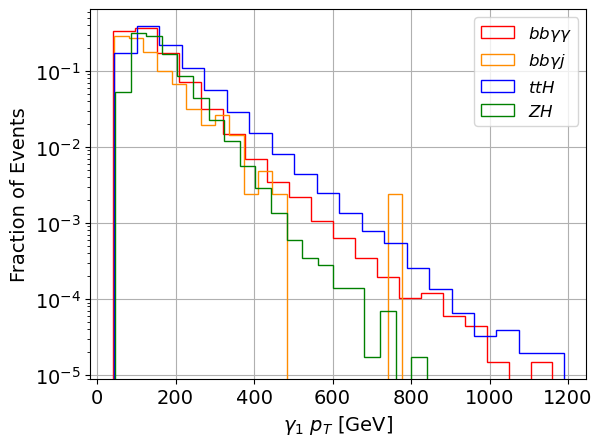

In [29]:
Nbins=20

weights = np.ones_like(pho1_bbaa[:,0])/float(len(pho1_bbaa[:,0]))
plt.hist(pho1_bbaa[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho1_bbaj[:,0])/float(len(pho1_bbaj[:,0]))
plt.hist(pho1_bbaj[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho1_tth[:,0])/float(len(pho1_tth[:,0]))
plt.hist(pho1_tth[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='blue', histtype='step', label="$ttH$")
weights = np.ones_like(pho1_zh[:,0])/float(len(pho1_zh[:,0]))
plt.hist(pho1_zh[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='green', histtype='step', label="$ZH$")

plt.grid()  # Add grid lines
# plt.title(title,fontsize=14)  # Titles etc
plt.xlabel("$\gamma_1$ $p_T$ [GeV]",fontsize=14)
plt.ylabel("Fraction of Events",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper right',fontsize=12)
plt.show()

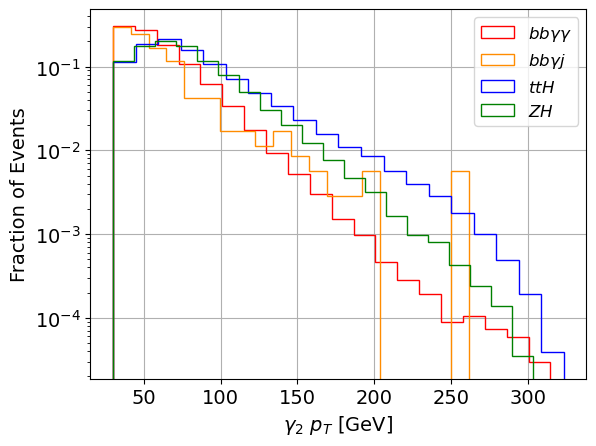

In [32]:
Nbins=20

weights = np.ones_like(pho2_bbaa[:,0])/float(len(pho2_bbaa[:,0]))
plt.hist(pho2_bbaa[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho2_bbaj_noFAKES[:,0])/float(len(pho2_bbaj_noFAKES[:,0]))
plt.hist(pho2_bbaj_noFAKES[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho2_tth[:,0])/float(len(pho2_tth[:,0]))
plt.hist(pho2_tth[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='blue', histtype='step', label="$ttH$")
weights = np.ones_like(pho2_zh[:,0])/float(len(pho2_zh[:,0]))
plt.hist(pho2_zh[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='green', histtype='step', label="$ZH$")

plt.grid()  # Add grid lines
# plt.title(title,fontsize=14)  # Titles etc
plt.xlabel("$\gamma_2$ $p_T$ [GeV]",fontsize=14)
plt.ylabel("Fraction of Events",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper right',fontsize=12)
plt.show()

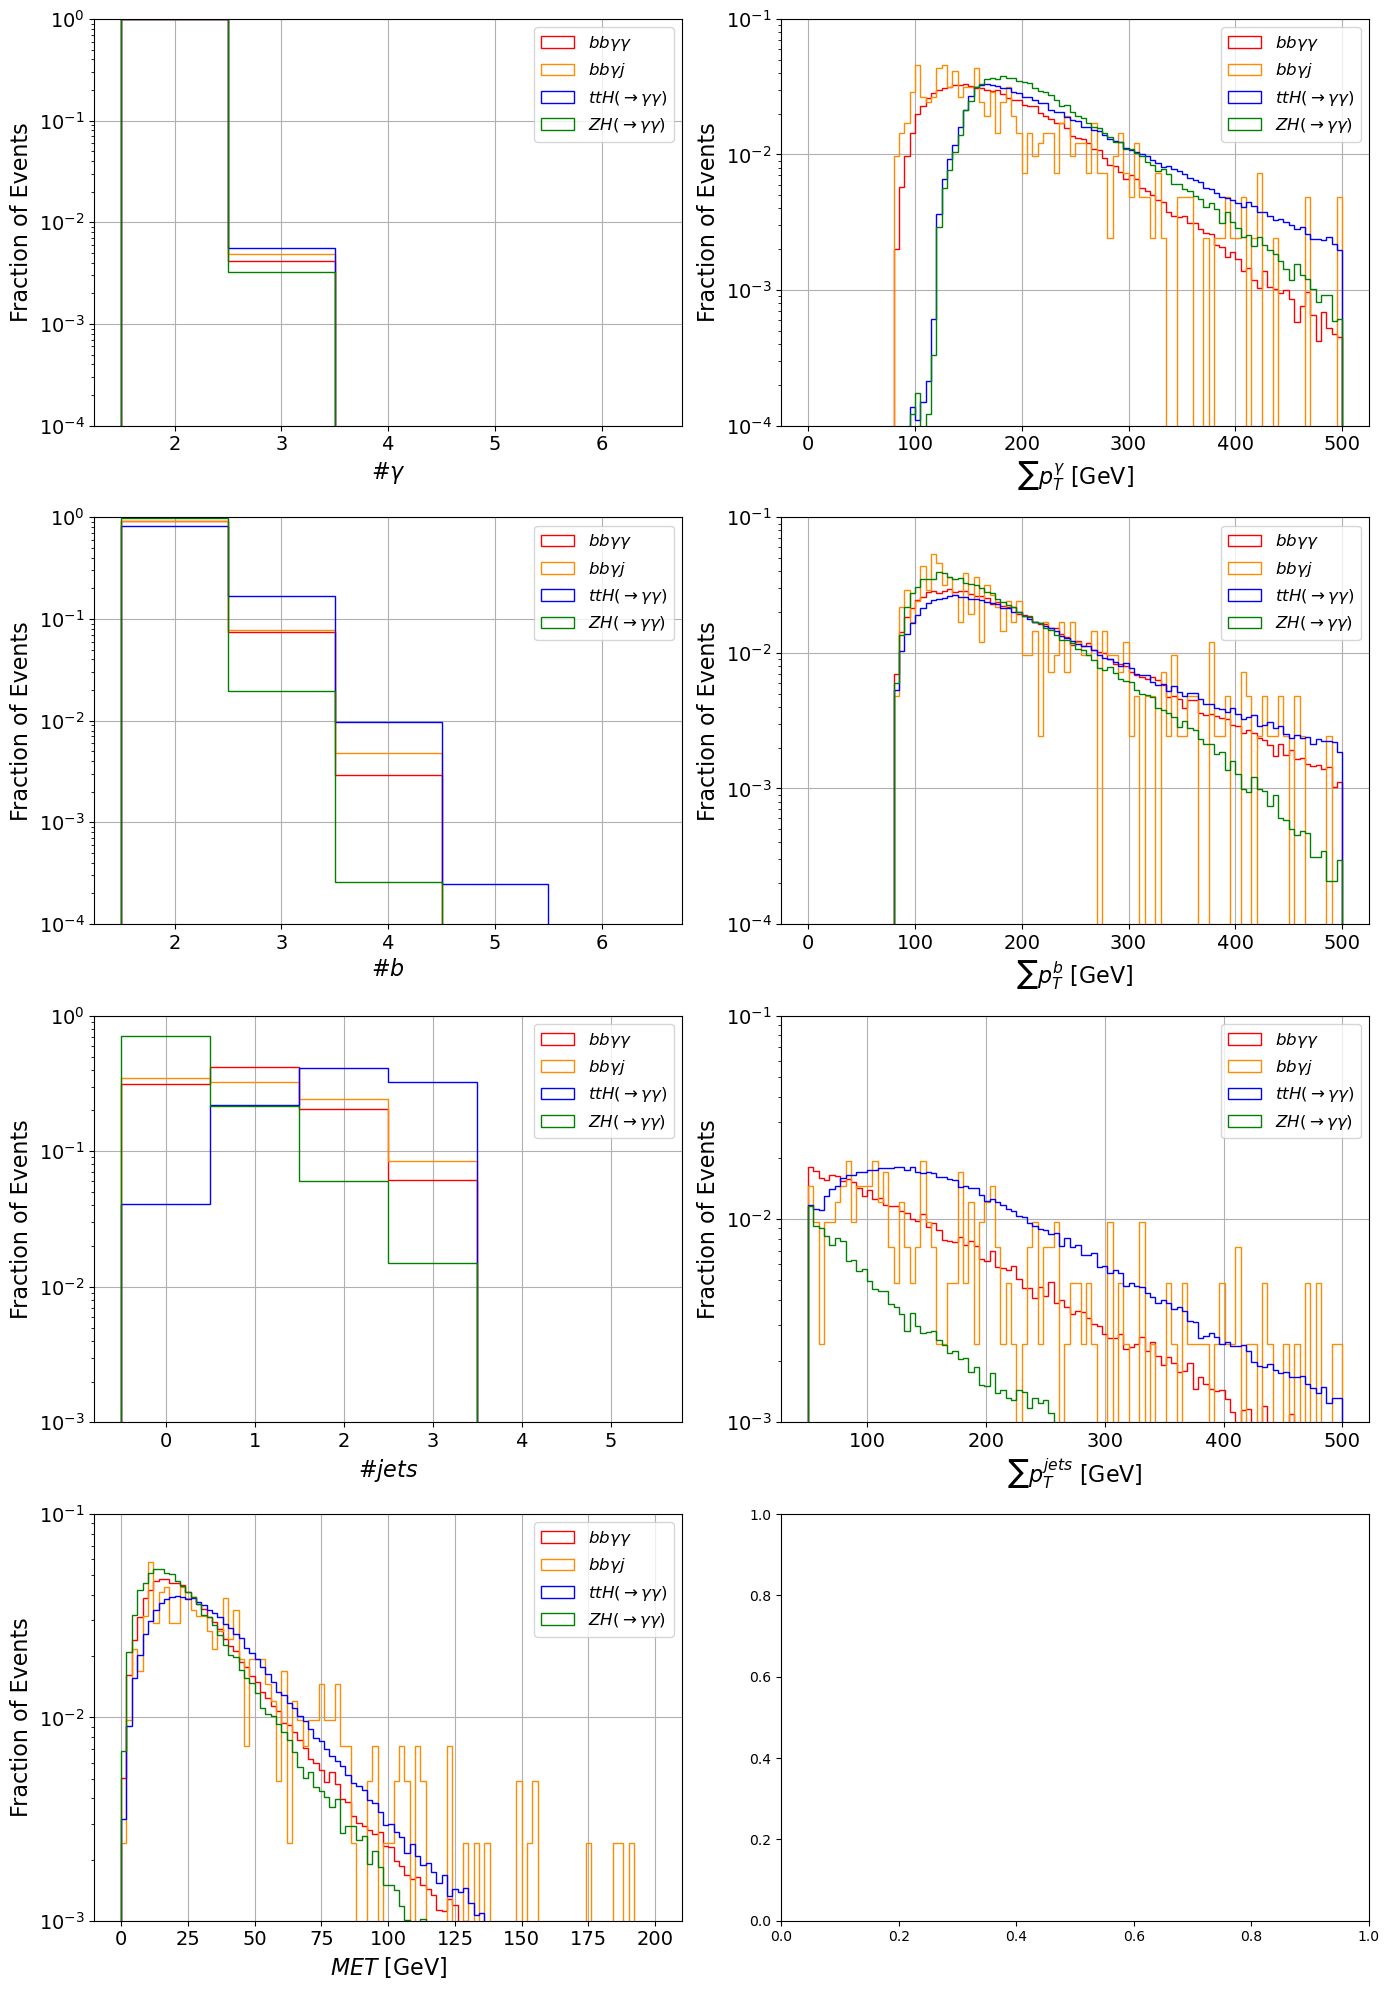

In [263]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# N gamma
ax = axes[0]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(pho_n_bbaa)/float(len(pho_n_bbaa))
ax.hist(pho_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_n_bbaj)/float(len(pho_n_bbaj))
ax.hist(pho_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_n_tth)/float(len(pho_n_tth))
ax.hist(pho_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_n_zh)/float(len(pho_n_zh))
ax.hist(pho_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$\gamma$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT gamma
ax = axes[1]
Nbins= 100
rang = [0,500]

weights = np.ones_like(pho_sumpt_bbaa)/float(len(pho_sumpt_bbaa))
ax.hist(pho_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_sumpt_bbaj)/float(len(pho_sumpt_bbaj))
ax.hist(pho_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_sumpt_tth)/float(len(pho_sumpt_tth))
ax.hist(pho_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_sumpt_zh)/float(len(pho_sumpt_zh))
ax.hist(pho_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# N bs
ax = axes[2]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(b_n_bbaa)/float(len(b_n_bbaa))
ax.hist(b_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_n_bbaj)/float(len(b_n_bbaj))
ax.hist(b_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_n_tth)/float(len(b_n_tth))
ax.hist(b_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_n_zh)/float(len(b_n_zh))
ax.hist(b_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$b$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT bs
ax = axes[3]
Nbins= 100
rang = [0,500]

weights = np.ones_like(b_sumpt_bbaa)/float(len(b_sumpt_bbaa))
ax.hist(b_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_sumpt_bbaj)/float(len(b_sumpt_bbaj))
ax.hist(b_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_sumpt_tth)/float(len(b_sumpt_tth))
ax.hist(b_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_sumpt_zh)/float(len(b_sumpt_zh))
ax.hist(b_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{b}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# N jets
ax = axes[4]
Nbins= 6
rang = [-0.5,5.5]

weights = np.ones_like(jet_n_bbaa)/float(len(jet_n_bbaa))
ax.hist(jet_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_n_bbaj)/float(len(jet_n_bbaj))
ax.hist(jet_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_n_tth)/float(len(jet_n_tth))
ax.hist(jet_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_n_zh)/float(len(jet_n_zh))
ax.hist(jet_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("#$jets$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT jets
ax = axes[5]
Nbins= 100
rang = [50,500]

weights = np.ones_like(jet_sumpt_bbaa)/float(len(jet_sumpt_bbaa))
ax.hist(jet_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_sumpt_bbaj)/float(len(jet_sumpt_bbaj))
ax.hist(jet_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_sumpt_tth)/float(len(jet_sumpt_tth))
ax.hist(jet_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_sumpt_zh)/float(len(jet_sumpt_zh))
ax.hist(jet_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$\sum p_T^{jets}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# MET
ax = axes[6]
Nbins= 100
rang = [0,200]

weights = np.ones_like(MET_bbaa[:,0])/float(len(MET_bbaa[:,0]))
ax.hist(MET_bbaa[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(MET_bbaj[:,0])/float(len(MET_bbaj[:,0]))
ax.hist(MET_bbaj[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(MET_tth[:,0])/float(len(MET_tth[:,0]))
ax.hist(MET_tth[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(MET_zh[:,0])/float(len(MET_zh[:,0]))
ax.hist(MET_zh[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$MET$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

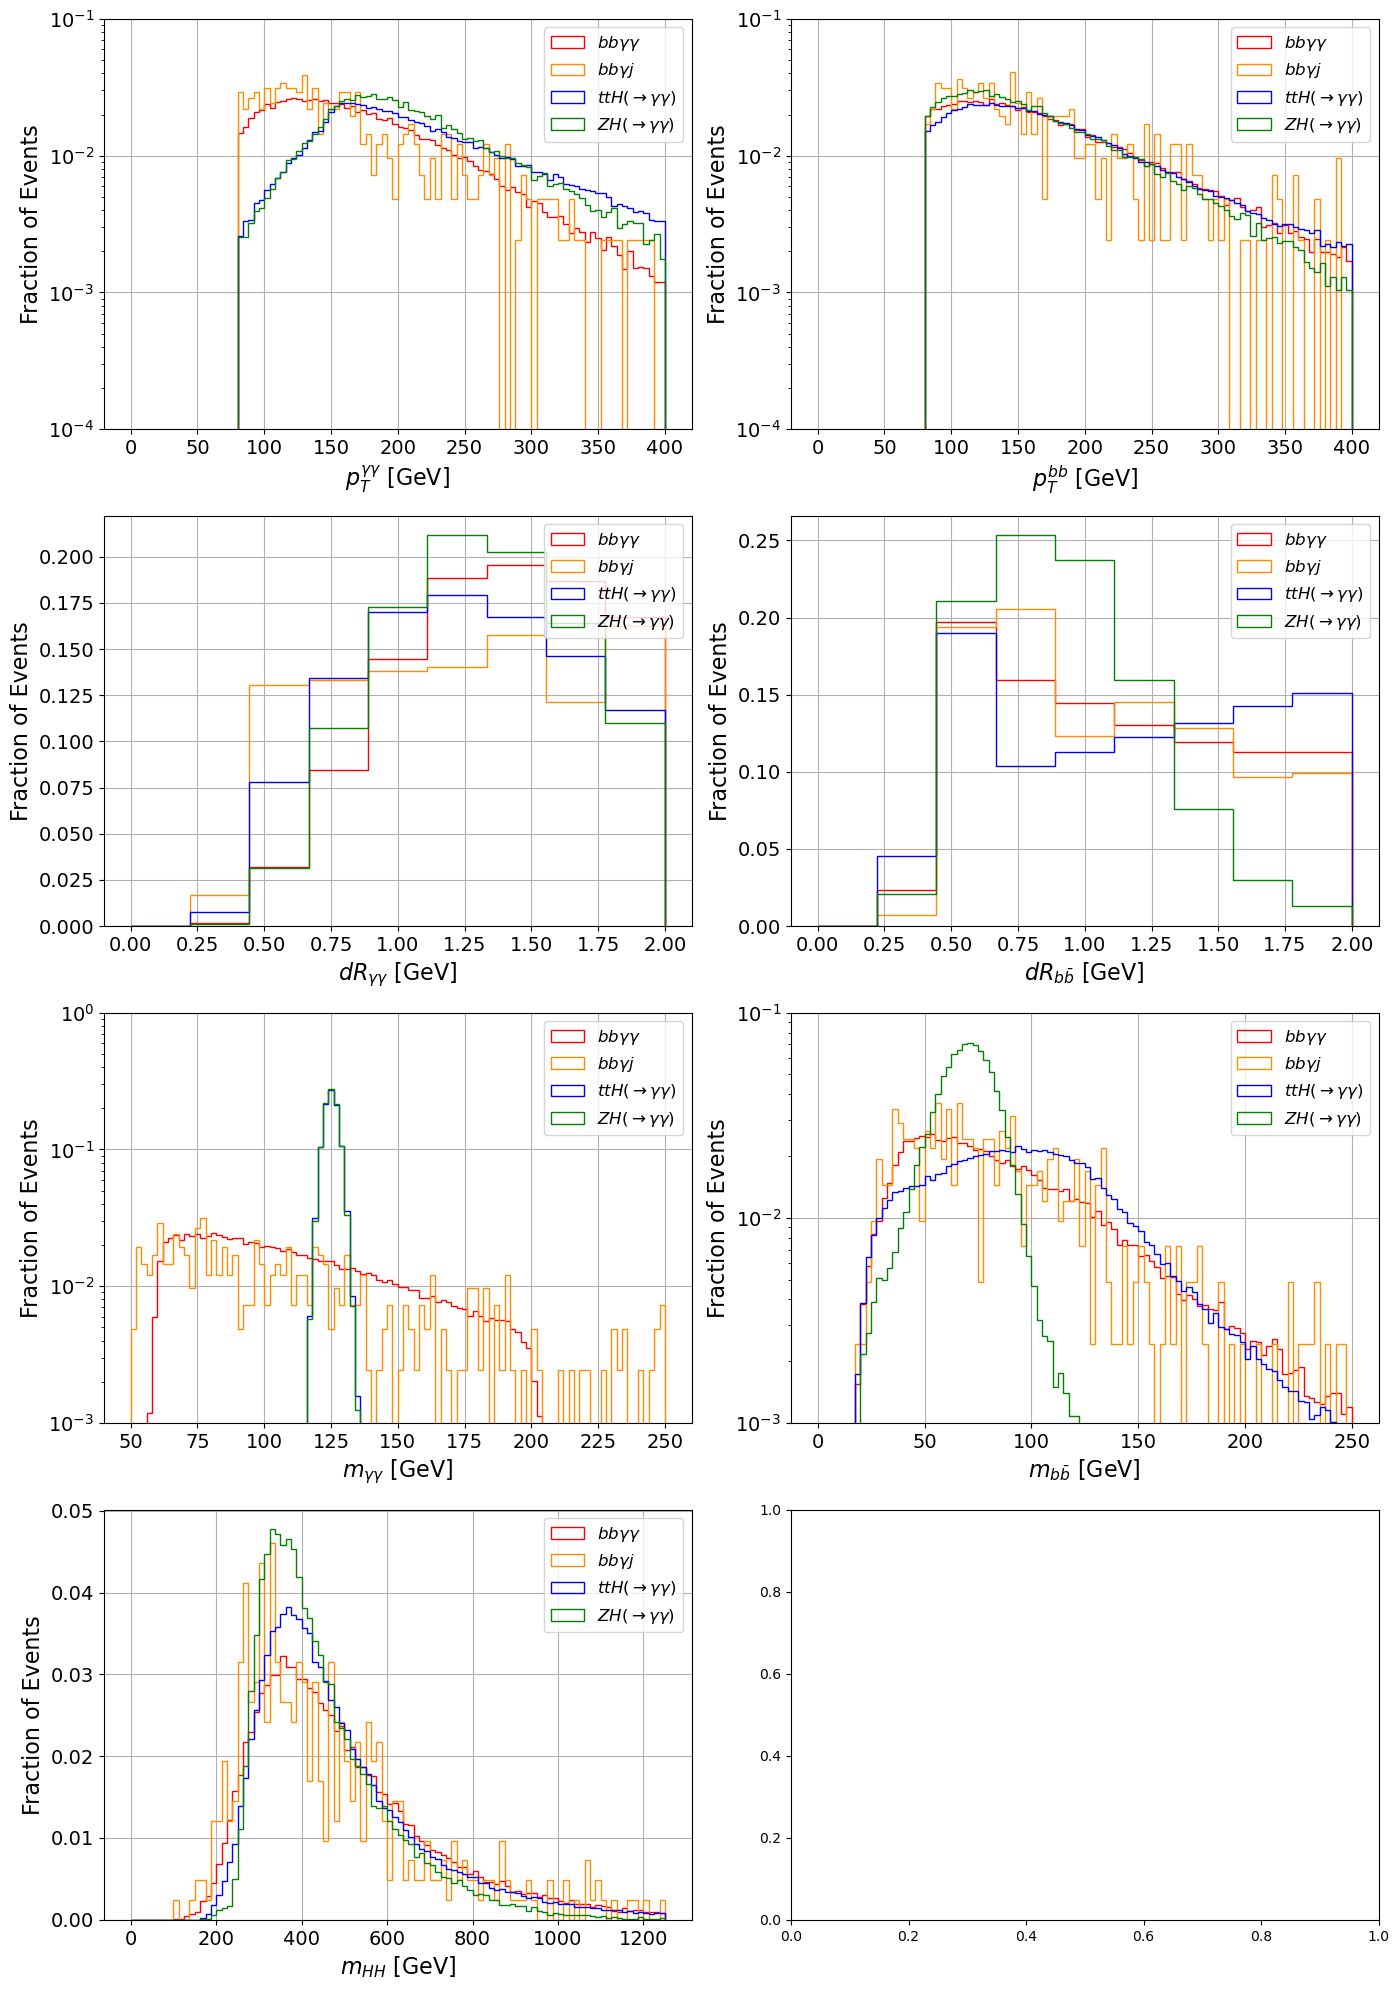

In [265]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# pT_pp
ax = axes[0]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_pho1_pho2_bbaa)/float(len(pT_pho1_pho2_bbaa))
ax.hist(pT_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_pho1_pho2_bbaj)/float(len(pT_pho1_pho2_bbaj))
ax.hist(pT_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_pho1_pho2_tth)/float(len(pT_pho1_pho2_tth))
ax.hist(pT_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_pho1_pho2_zh)/float(len(pT_pho1_pho2_zh))
ax.hist(pT_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# pT_bb
ax = axes[1]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_b1_b2_bbaa)/float(len(pT_b1_b2_bbaa))
ax.hist(pT_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_b1_b2_bbaj)/float(len(pT_b1_b2_bbaj))
ax.hist(pT_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_b1_b2_tth)/float(len(pT_b1_b2_tth))
ax.hist(pT_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_b1_b2_zh)/float(len(pT_b1_b2_zh))
ax.hist(pT_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{bb}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_pp
ax = axes[2]
Nbins= 9
rang = [0,2]

weights = np.ones_like(dR_pho1_pho2_bbaa)/float(len(dR_pho1_pho2_bbaa))
ax.hist(dR_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_pho1_pho2_bbaj)/float(len(dR_pho1_pho2_bbaj))
ax.hist(dR_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_pho1_pho2_tth)/float(len(dR_pho1_pho2_tth))
ax.hist(dR_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_pho1_pho2_zh)/float(len(dR_pho1_pho2_zh))
ax.hist(dR_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
# ax.set_ylim(1e-3,1)
ax.set_xlabel("$dR_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
# ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_bb
ax = axes[3]
Nbins= 9
rang = [0,2]

weights = np.ones_like(dR_b1_b2_bbaa)/float(len(dR_b1_b2_bbaa))
ax.hist(dR_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_b1_b2_bbaj)/float(len(dR_b1_b2_bbaj))
ax.hist(dR_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_b1_b2_tth)/float(len(dR_b1_b2_tth))
ax.hist(dR_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_b1_b2_zh)/float(len(dR_b1_b2_zh))
ax.hist(dR_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
# ax.set_ylim(1e-2,1)
ax.set_xlabel(r"$dR_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
# ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# m_pp
ax = axes[4]
Nbins= 100
rang = [50,250]

weights = np.ones_like(m_pho1_pho2_bbaa)/float(len(m_pho1_pho2_bbaa))
ax.hist(m_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_pho1_pho2_bbaj)/float(len(m_pho1_pho2_bbaj))
ax.hist(m_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_pho1_pho2_tth)/float(len(m_pho1_pho2_tth))
ax.hist(m_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_pho1_pho2_zh)/float(len(m_pho1_pho2_zh))
ax.hist(m_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("$m_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_bb
ax = axes[5]
Nbins= 100
rang = [0,250]

weights = np.ones_like(m_b1_b2_bbaa)/float(len(m_b1_b2_bbaa))
ax.hist(m_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_b1_b2_bbaj)/float(len(m_b1_b2_bbaj))
ax.hist(m_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_b1_b2_tth)/float(len(m_b1_b2_tth))
ax.hist(m_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_b1_b2_zh)/float(len(m_b1_b2_zh))
ax.hist(m_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$m_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_HH
ax = axes[6]
Nbins= 100
rang = [0,1250]

weights = np.ones_like(m_HH_bbaa)/float(len(m_HH_bbaa))
ax.hist(m_HH_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_HH_bbaj)/float(len(m_HH_bbaj))
ax.hist(m_HH_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_HH_tth)/float(len(m_HH_tth))
ax.hist(m_HH_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_HH_zh)/float(len(m_HH_zh))
ax.hist(m_HH_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
# ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$m_{HH}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
# ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

#  ALL CUTS

In [13]:
import itertools

MH = 125.0

# TRY ALL POSSIBLE COMBINATIONS ADN KEEP THE ONE THAT IS CLOSEST TO THE HIGGS MASS
def best_pair_mass(particles):
    """
    particles: array (N,3) with [pt, eta, phi]
    returns: indices (i,j), mass
    """
    best = None
    best_dm = 1e9

    for i, j in itertools.combinations(range(len(particles)), 2):
        m = inv_mass(particles[i:i+1], particles[j:j+1])[0]
        dm = abs(m - MH)
        if dm < best_dm:
            best_dm = dm
            best = (i, j, m)

    return best  # (i, j, m)



def pass_HH_extra_cuts(photons, bjets, jets):
    """
    photons, bjets, jets: arrays with [pt, eta, phi]
    """

    # --- need at least 2 and 2 ---
    if len(photons) < 2 or len(bjets) < 2:
        return False, None, None, None, None

    # --- choose best Higgs candidates ---
    ip, jp, m_phopho = best_pair_mass(photons)
    ib, jb, m_bb = best_pair_mass(bjets)

    pho1, pho2 = photons[ip], photons[jp]
    b1, b2 = bjets[ib], bjets[jb]

    # --- mass windows ---
    if not (122 < m_phopho < 128):
        return False, None, None, None, None
    if not (80 < m_bb < 130):
        return False, None, None, None, None

    # --- ΔR cuts ---
    if not (0.4 < delta_R(pho1[None,:], pho2[None,:])[0] < 2.0):
        return False, None, None, None, None
    if not (0.4 < delta_R(b1[None,:], b2[None,:])[0] < 2.0):
        return False, None, None, None, None

    # --- pT of Higgs candidates ---
    if pT12(pho1[None,:], pho2[None,:])[0] < 80:
        return False, None, None, None, None
    if pT12(b1[None,:], b2[None,:])[0] < 80:
        return False, None, None, None, None

    # --- ΔR(γ, j) isolation ---
    for phot in [pho1, pho2]:
        for j in jets:
            if delta_R(phot[None,:], j[None,:])[0] < 0.4:
                return False, None, None, None, None

    return True, ip, jp, ib, jb

#### Signal point-1

In [14]:
filename = "../DATA/signal/point1.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (191677,)
 pho1_S1.shape:  (75973, 3)


In [15]:
initial_evs = 191677
events_ok = 75973

cross_basic_cuts_fb = 0.02659216426864612 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.010540056949878451 [fb]
Events expected:  31.620170849635354     for L= 3000  [fb-1]


#### bbaa

In [168]:
filename = "../DATA/backgrounds/bbaa.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaa = []
pho_sumpt_bbaa = []

jet_n_bbaa = []
jet_sumpt_bbaa = []

b_n_bbaa = []
b_sumpt_bbaa = []


pho1_bbaa = []
pho2_bbaa = []

b1_bbaa = []
b2_bbaa = []

MET_bbaa = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaa.append( len(photon_pt[iev]) )
        pho_sumpt_bbaa.append( sum(photon_pt[iev]) ) 

        jet_n_bbaa.append( len(jet_pt[iev]) )
        jet_sumpt_bbaa.append( sum(jet_pt[iev]) ) 

        b_n_bbaa.append( len(btag_pt[iev]) )
        b_sumpt_bbaa.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaa.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaa.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaa.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaa.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaa.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaa = np.asarray(pho_n_bbaa)
pho_sumpt_bbaa = np.asarray(pho_sumpt_bbaa)

jet_n_bbaa = np.asarray(jet_n_bbaa)
jet_sumpt_bbaa = np.asarray(jet_sumpt_bbaa)

b_n_bbaa = np.asarray(b_n_bbaa)
b_sumpt_bbaa = np.asarray(b_sumpt_bbaa)


pho1_bbaa = np.asarray(pho1_bbaa)
pho2_bbaa = np.asarray(pho2_bbaa)

b1_bbaa = np.asarray(b1_bbaa)
b2_bbaa = np.asarray(b2_bbaa)

MET_bbaa = np.asarray(MET_bbaa)




print(" pho1_bbaa.shape: ", pho1_bbaa.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (380952,)
 pho1_bbaa.shape:  (922, 3)


In [182]:
initial_evs = 380952
events_ok = 922

cross_basic_cuts_fb = 2.171428463266681 # fb

In [183]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.005255404993626179 [fb]
Events expected:  15.766214980878535     for L= 3000  [fb-1]


#### bbaj (NO FAKES)

In [224]:
filename = "../DATA/backgrounds/bbaj_noFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj_noFAKES = []
pho_sumpt_bbaj_noFAKES = []

jet_n_bbaj_noFAKES = []
jet_sumpt_bbaj_noFAKES = []

b_n_bbaj_noFAKES = []
b_sumpt_bbaj_noFAKES = []


pho1_bbaj_noFAKES = []
pho2_bbaj_noFAKES = []

b1_bbaj_noFAKES = []
b2_bbaj_noFAKES = []

MET_bbaj_noFAKES = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj_noFAKES.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj_noFAKES.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj_noFAKES.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj_noFAKES.append( sum(jet_pt[iev]) ) 

        b_n_bbaj_noFAKES.append( len(btag_pt[iev]) )
        b_sumpt_bbaj_noFAKES.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj_noFAKES.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj_noFAKES.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj_noFAKES.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj_noFAKES.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj_noFAKES.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaj_noFAKES = np.asarray(pho_n_bbaj_noFAKES)
pho_sumpt_bbaj_noFAKES = np.asarray(pho_sumpt_bbaj_noFAKES)

jet_n_bbaj_noFAKES = np.asarray(jet_n_bbaj_noFAKES)
jet_sumpt_bbaj_noFAKES = np.asarray(jet_sumpt_bbaj_noFAKES)

b_n_bbaj_noFAKES = np.asarray(b_n_bbaj_noFAKES)
b_sumpt_bbaj_noFAKES = np.asarray(b_sumpt_bbaj_noFAKES)


pho1_bbaj_noFAKES = np.asarray(pho1_bbaj_noFAKES)
pho2_bbaj_noFAKES = np.asarray(pho2_bbaj_noFAKES)

b1_bbaj_noFAKES = np.asarray(b1_bbaj_noFAKES)
b2_bbaj_noFAKES = np.asarray(b2_bbaj_noFAKES)

MET_bbaj_noFAKES = np.asarray(MET_bbaj_noFAKES)


print(" pho1_bbaj_noFAKES.shape: ", pho1_bbaj_noFAKES.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2428,)
 pho1_bbaj_noFAKES.shape:  (2, 3)


In [229]:
initial_evs = 2428
events_ok = 2

cross_basic_cuts_fb = 16.790270624904363 # fb

In [230]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.013830535934847087 [fb]
Events expected:  41.49160780454126     for L= 3000  [fb-1]


#### bbaj (with FAKES)

In [171]:
filename = "../DATA/backgrounds/bbaj_wFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj = []
pho_sumpt_bbaj = []

jet_n_bbaj = []
jet_sumpt_bbaj = []

b_n_bbaj = []
b_sumpt_bbaj = []


pho1_bbaj = []
pho2_bbaj = []

b1_bbaj = []
b2_bbaj = []

MET_bbaj = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj.append( sum(jet_pt[iev]) ) 

        b_n_bbaj.append( len(btag_pt[iev]) )
        b_sumpt_bbaj.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaj = np.asarray(pho_n_bbaj)
pho_sumpt_bbaj = np.asarray(pho_sumpt_bbaj)

jet_n_bbaj = np.asarray(jet_n_bbaj)
jet_sumpt_bbaj = np.asarray(jet_sumpt_bbaj)

b_n_bbaj = np.asarray(b_n_bbaj)
b_sumpt_bbaj = np.asarray(b_sumpt_bbaj)


pho1_bbaj = np.asarray(pho1_bbaj)
pho2_bbaj = np.asarray(pho2_bbaj)

b1_bbaj = np.asarray(b1_bbaj)
b2_bbaj = np.asarray(b2_bbaj)

MET_bbaj = np.asarray(MET_bbaj)


print(" pho1_bbaj.shape: ", pho1_bbaj.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2802,)
 pho1_bbaj.shape:  (3, 3)


In [172]:
initial_evs = 2802
events_ok = 3

cross_basic_cuts_fb = 19.386077717379234 # fb

In [173]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.020755971860149075 [fb]
Events expected:  62.26791558044722     for L= 3000  [fb-1]


In [184]:
cross_basic_cuts_fb = 2.5236714365053565 # fb

In [185]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.0061079219021239915 [fb]
Events expected:  18.323765706371976     for L= 3000  [fb-1]


#### tth

In [174]:
filename = "../DATA/backgrounds/tth.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_tth = []
pho_sumpt_tth = []

jet_n_tth = []
jet_sumpt_tth = []

b_n_tth = []
b_sumpt_tth = []


pho1_tth = []
pho2_tth = []

b1_tth = []
b2_tth = []

MET_tth = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_tth.append( len(photon_pt[iev]) )
        pho_sumpt_tth.append( sum(photon_pt[iev]) ) 

        jet_n_tth.append( len(jet_pt[iev]) )
        jet_sumpt_tth.append( sum(jet_pt[iev]) ) 

        b_n_tth.append( len(btag_pt[iev]) )
        b_sumpt_tth.append( sum(btag_pt[iev]) ) 

        
        pho1_tth.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_tth.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_tth.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_tth.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_tth.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_tth = np.asarray(pho_n_tth)
pho_sumpt_tth = np.asarray(pho_sumpt_tth)

jet_n_tth = np.asarray(jet_n_tth)
jet_sumpt_tth = np.asarray(jet_sumpt_tth)

b_n_tth = np.asarray(b_n_tth)
b_sumpt_tth = np.asarray(b_sumpt_tth)


pho1_tth = np.asarray(pho1_tth)
pho2_tth = np.asarray(pho2_tth)

b1_tth = np.asarray(b1_tth)
b2_tth = np.asarray(b2_tth)

MET_tth = np.asarray(MET_tth)


print(" pho1_tth.shape: ", pho1_tth.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (606082,)
 pho1_tth.shape:  (43613, 3)


In [175]:
initial_evs = 606082
events_ok = 43613

cross_basic_cuts_fb = 0.033768365117857184 # fb

In [176]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.0024299347413140556 [fb]
Events expected:  7.289804223942167     for L= 3000  [fb-1]


#### zh

In [177]:
filename = "../DATA/backgrounds/zh.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_zh = []
pho_sumpt_zh = []

jet_n_zh = []
jet_sumpt_zh = []

b_n_zh = []
b_sumpt_zh = []


pho1_zh = []
pho2_zh = []

b1_zh = []
b2_zh = []

MET_zh = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_zh.append( len(photon_pt[iev]) )
        pho_sumpt_zh.append( sum(photon_pt[iev]) ) 

        jet_n_zh.append( len(jet_pt[iev]) )
        jet_sumpt_zh.append( sum(jet_pt[iev]) ) 

        b_n_zh.append( len(btag_pt[iev]) )
        b_sumpt_zh.append( sum(btag_pt[iev]) ) 

        
        pho1_zh.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_zh.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_zh.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_zh.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_zh.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_zh = np.asarray(pho_n_zh)
pho_sumpt_zh = np.asarray(pho_sumpt_zh)

jet_n_zh = np.asarray(jet_n_zh)
jet_sumpt_zh = np.asarray(jet_sumpt_zh)

b_n_zh = np.asarray(b_n_zh)
b_sumpt_zh = np.asarray(b_sumpt_zh)


pho1_zh = np.asarray(pho1_zh)
pho2_zh = np.asarray(pho2_zh)

b1_zh = np.asarray(b1_zh)
b2_zh = np.asarray(b2_zh)

MET_zh = np.asarray(MET_zh)


print(" pho1_zh.shape: ", pho1_zh.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (83047,)
 pho1_zh.shape:  (8950, 3)


In [178]:
initial_evs = 83047
events_ok = 8950

cross_basic_cuts_fb = 0.006521839124728637 # fb

In [179]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.0007028605508485713 [fb]
Events expected:  2.108581652545714     for L= 3000  [fb-1]


### HIGH LEVEL FEATURES

In [231]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""
    
    phi1 = p1[:,2]
    phi2 = p2[:,2]
    
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""
    
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]
    
    
    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    
    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)
    
    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def inv_mass_4vec(px, py, pz, E):
    """invariant mass (massless particles approx). 
    But for 4 vectors"""
    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]
    
    pt2 = p2[:,0]
    phi2 = p2[:,2]
    
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]
    
    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)
    
    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:] 
    
    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)
    
    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )



def higgs_four_vector(p1, p2):
    """
    reconstruct the four vector of the mother particle (assuming it decays to p1 and p2)
    """
    pt1, eta1, phi1 = p1.T
    pt2, eta2, phi2 = p2.T

    px = pt1*np.cos(phi1) + pt2*np.cos(phi2)
    py = pt1*np.sin(phi1) + pt2*np.sin(phi2)
    pz = pt1*np.sinh(eta1) + pt2*np.sinh(eta2)
    E  = pt1*np.cosh(eta1) + pt2*np.cosh(eta2)

    return px, py, pz, E

In [232]:
# delta R
dR_pho1_pho2_bbaa = delta_R(pho1_bbaa, pho2_bbaa)
dR_b1_b2_bbaa = delta_R(b1_bbaa, b2_bbaa)

dR_pho1_b1_bbaa = delta_R(pho1_bbaa, b1_bbaa)
dR_pho1_b2_bbaa = delta_R(pho1_bbaa, b2_bbaa)

dR_pho2_b1_bbaa = delta_R(pho2_bbaa, b1_bbaa)
dR_pho2_b2_bbaa = delta_R(pho2_bbaa, b2_bbaa)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaa = pT12(pho1_bbaa, pho2_bbaa)
pT_b1_b2_bbaa = pT12(b1_bbaa, b2_bbaa)

pT_pho1_b1_bbaa = pT12(pho1_bbaa, b1_bbaa)
pT_pho1_b2_bbaa = pT12(pho1_bbaa, b2_bbaa)

pT_pho2_b1_bbaa = pT12(pho2_bbaa, b1_bbaa)
pT_pho2_b2_bbaa = pT12(pho2_bbaa, b2_bbaa)


# invariant mass
m_pho1_pho2_bbaa = inv_mass(pho1_bbaa, pho2_bbaa)
m_b1_b2_bbaa = inv_mass(b1_bbaa, b2_bbaa)

m_pho1_b1_bbaa = inv_mass(pho1_bbaa, b1_bbaa)
m_pho1_b2_bbaa = inv_mass(pho1_bbaa, b2_bbaa)

m_pho2_b1_bbaa = inv_mass(pho2_bbaa, b1_bbaa)
m_pho2_b2_bbaa = inv_mass(pho2_bbaa, b2_bbaa)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaa, b2_bbaa)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaa, pho2_bbaa)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaa = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [233]:
# delta R
dR_pho1_pho2_bbaj = delta_R(pho1_bbaj, pho2_bbaj)
dR_b1_b2_bbaj = delta_R(b1_bbaj, b2_bbaj)

dR_pho1_b1_bbaj = delta_R(pho1_bbaj, b1_bbaj)
dR_pho1_b2_bbaj = delta_R(pho1_bbaj, b2_bbaj)

dR_pho2_b1_bbaj = delta_R(pho2_bbaj, b1_bbaj)
dR_pho2_b2_bbaj = delta_R(pho2_bbaj, b2_bbaj)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_bbaj = pT12(pho1_bbaj, pho2_bbaj)
pT_b1_b2_bbaj = pT12(b1_bbaj, b2_bbaj)

pT_pho1_b1_bbaj = pT12(pho1_bbaj, b1_bbaj)
pT_pho1_b2_bbaj = pT12(pho1_bbaj, b2_bbaj)

pT_pho2_b1_bbaj = pT12(pho2_bbaj, b1_bbaj)
pT_pho2_b2_bbaj = pT12(pho2_bbaj, b2_bbaj)


# invariant mass
m_pho1_pho2_bbaj = inv_mass(pho1_bbaj, pho2_bbaj)
m_b1_b2_bbaj = inv_mass(b1_bbaj, b2_bbaj)

m_pho1_b1_bbaj = inv_mass(pho1_bbaj, b1_bbaj)
m_pho1_b2_bbaj = inv_mass(pho1_bbaj, b2_bbaj)

m_pho2_b1_bbaj = inv_mass(pho2_bbaj, b1_bbaj)
m_pho2_b2_bbaj = inv_mass(pho2_bbaj, b2_bbaj)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_bbaj, b2_bbaj)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_bbaj, pho2_bbaj)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_bbaj = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [234]:
# delta R
dR_pho1_pho2_tth = delta_R(pho1_tth, pho2_tth)
dR_b1_b2_tth = delta_R(b1_tth, b2_tth)

dR_pho1_b1_tth = delta_R(pho1_tth, b1_tth)
dR_pho1_b2_tth = delta_R(pho1_tth, b2_tth)

dR_pho2_b1_tth = delta_R(pho2_tth, b1_tth)
dR_pho2_b2_tth = delta_R(pho2_tth, b2_tth)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_tth = pT12(pho1_tth, pho2_tth)
pT_b1_b2_tth = pT12(b1_tth, b2_tth)

pT_pho1_b1_tth = pT12(pho1_tth, b1_tth)
pT_pho1_b2_tth = pT12(pho1_tth, b2_tth)

pT_pho2_b1_tth = pT12(pho2_tth, b1_tth)
pT_pho2_b2_tth = pT12(pho2_tth, b2_tth)


# invariant mass
m_pho1_pho2_tth = inv_mass(pho1_tth, pho2_tth)
m_b1_b2_tth = inv_mass(b1_tth, b2_tth)

m_pho1_b1_tth = inv_mass(pho1_tth, b1_tth)
m_pho1_b2_tth = inv_mass(pho1_tth, b2_tth)

m_pho2_b1_tth = inv_mass(pho2_tth, b1_tth)
m_pho2_b2_tth = inv_mass(pho2_tth, b2_tth)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_tth, b2_tth)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_tth, pho2_tth)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_tth = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

In [235]:
# delta R
dR_pho1_pho2_zh = delta_R(pho1_zh, pho2_zh)
dR_b1_b2_zh = delta_R(b1_zh, b2_zh)

dR_pho1_b1_zh = delta_R(pho1_zh, b1_zh)
dR_pho1_b2_zh = delta_R(pho1_zh, b2_zh)

dR_pho2_b1_zh = delta_R(pho2_zh, b1_zh)
dR_pho2_b2_zh = delta_R(pho2_zh, b2_zh)


# transverse momenta of the p1 p2 system
pT_pho1_pho2_zh = pT12(pho1_zh, pho2_zh)
pT_b1_b2_zh = pT12(b1_zh, b2_zh)

pT_pho1_b1_zh = pT12(pho1_zh, b1_zh)
pT_pho1_b2_zh = pT12(pho1_zh, b2_zh)

pT_pho2_b1_zh = pT12(pho2_zh, b1_zh)
pT_pho2_b2_zh = pT12(pho2_zh, b2_zh)


# invariant mass
m_pho1_pho2_zh = inv_mass(pho1_zh, pho2_zh)
m_b1_b2_zh = inv_mass(b1_zh, b2_zh)

m_pho1_b1_zh = inv_mass(pho1_zh, b1_zh)
m_pho1_b2_zh = inv_mass(pho1_zh, b2_zh)

m_pho2_b1_zh = inv_mass(pho2_zh, b1_zh)
m_pho2_b2_zh = inv_mass(pho2_zh, b2_zh)


# Invariant mass of the reconstructed Higgs boson pair
px_bb, py_bb, pz_bb, E_bb = higgs_four_vector(b1_zh, b2_zh)
px_phopho, py_phopho, pz_phopho, E_phopho = higgs_four_vector(pho1_zh, pho2_zh)

px_HH = px_bb + px_phopho
py_HH = py_bb + py_phopho
pz_HH = pz_bb + pz_phopho
E_HH  = E_bb  + E_phopho

m_HH_zh = inv_mass_4vec(px_HH, py_HH, pz_HH, E_HH)

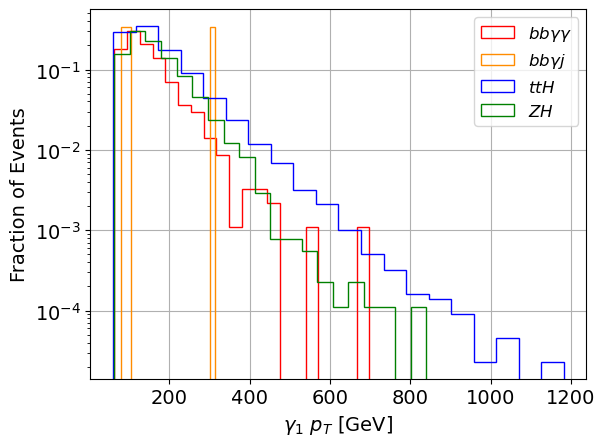

In [191]:
Nbins=20

weights = np.ones_like(pho1_bbaa[:,0])/float(len(pho1_bbaa[:,0]))
plt.hist(pho1_bbaa[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho1_bbaj[:,0])/float(len(pho1_bbaj[:,0]))
plt.hist(pho1_bbaj[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho1_tth[:,0])/float(len(pho1_tth[:,0]))
plt.hist(pho1_tth[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='blue', histtype='step', label="$ttH$")
weights = np.ones_like(pho1_zh[:,0])/float(len(pho1_zh[:,0]))
plt.hist(pho1_zh[:,0], weights=weights, bins=Nbins, lw=2, edgecolor='green', histtype='step', label="$ZH$")

plt.grid()  # Add grid lines
# plt.title(title,fontsize=14)  # Titles etc
plt.xlabel("$\gamma_1$ $p_T$ [GeV]",fontsize=14)
plt.ylabel("Fraction of Events",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper right',fontsize=12)
plt.show()

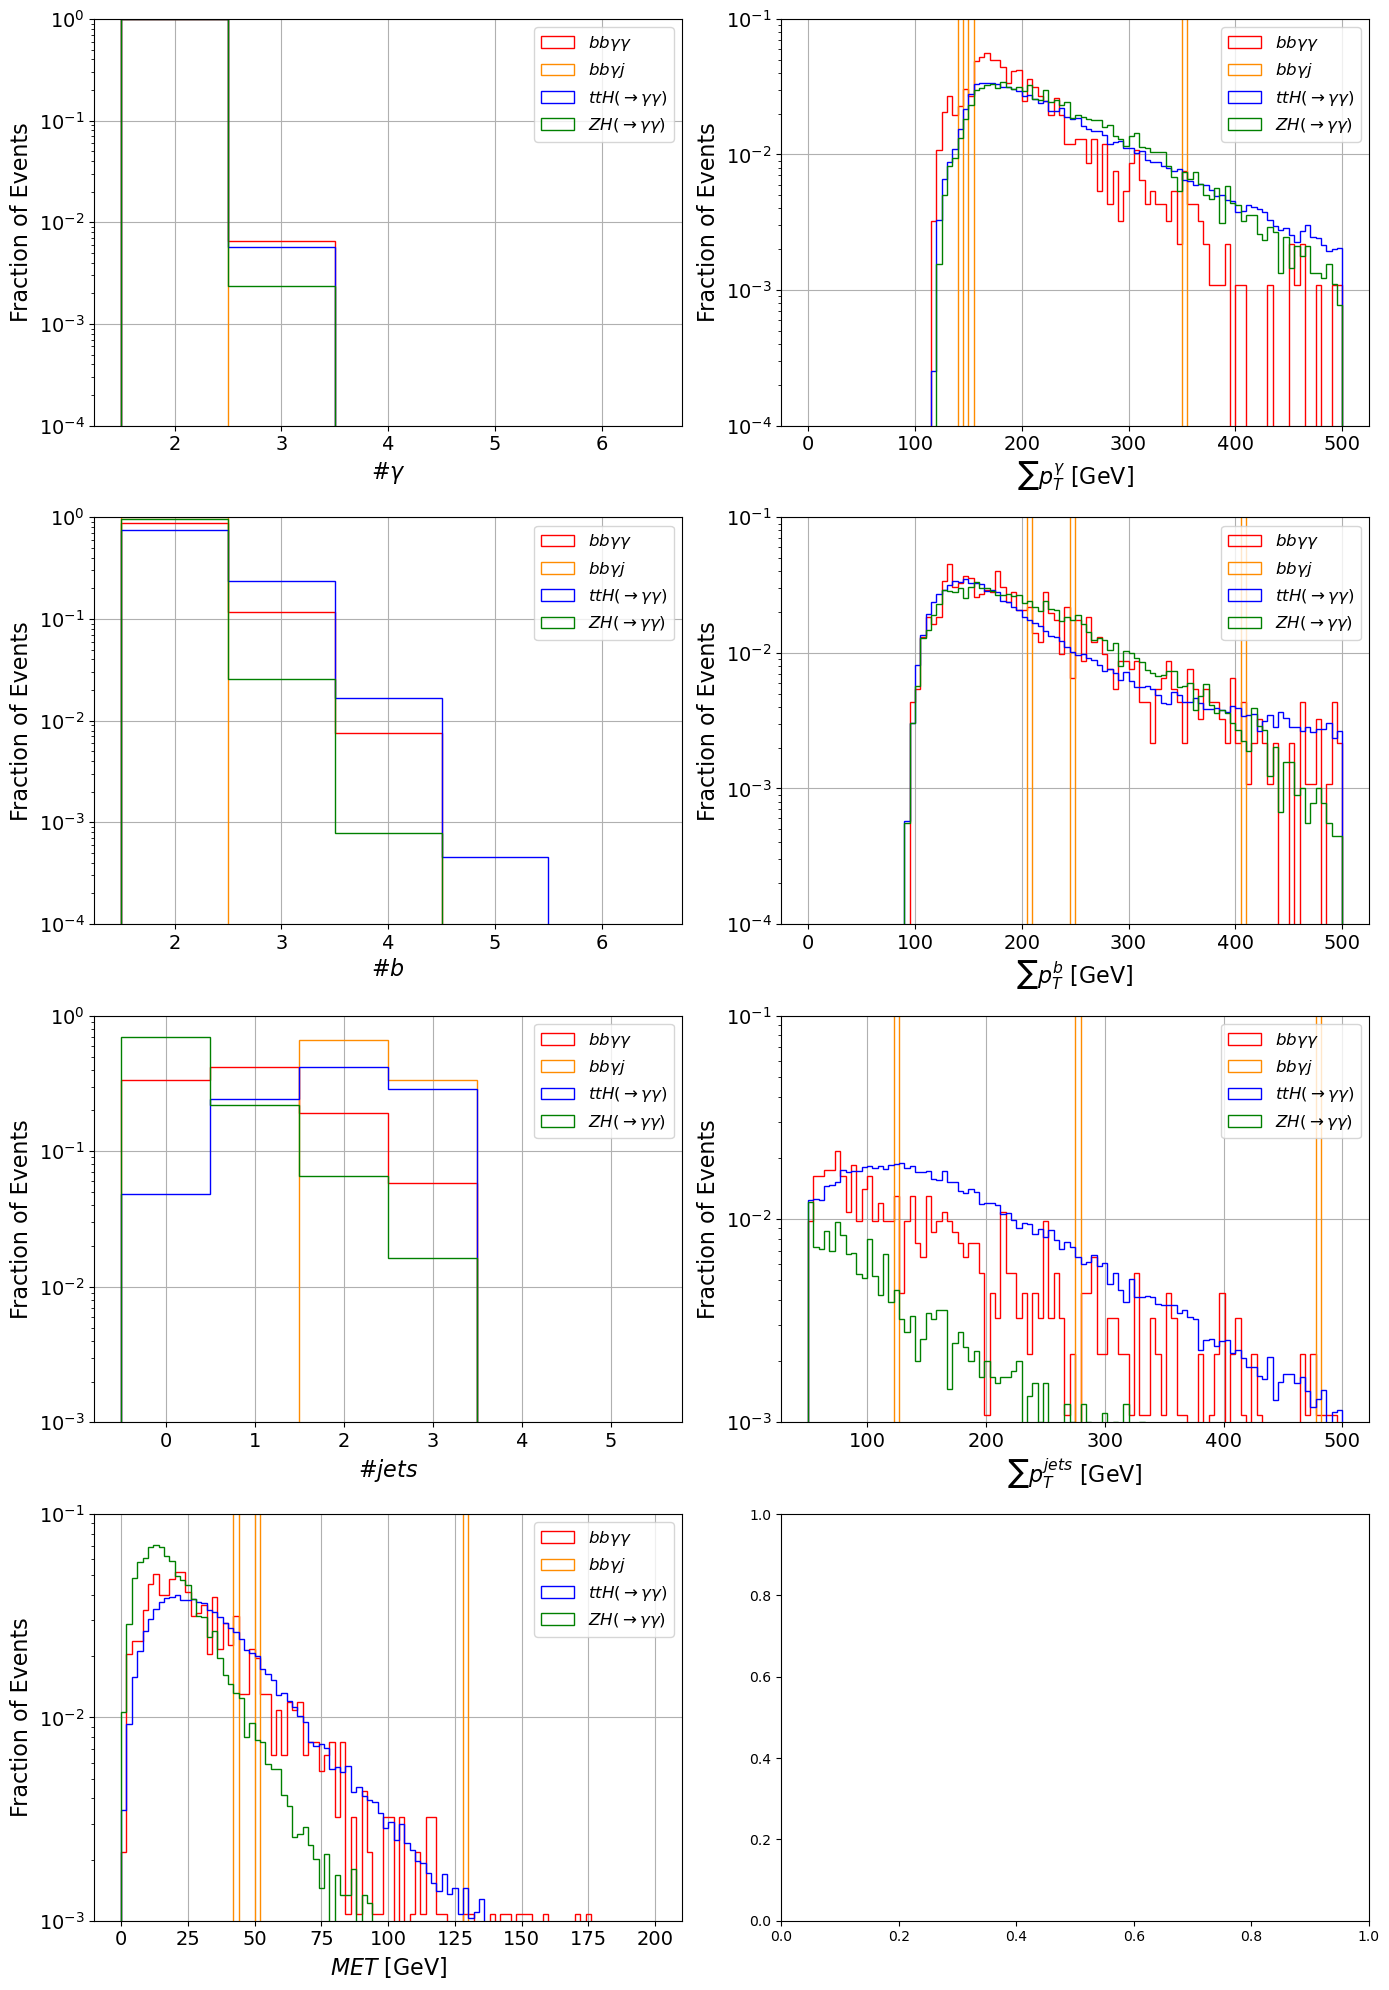

In [192]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# N gamma
ax = axes[0]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(pho_n_bbaa)/float(len(pho_n_bbaa))
ax.hist(pho_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_n_bbaj)/float(len(pho_n_bbaj))
ax.hist(pho_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_n_tth)/float(len(pho_n_tth))
ax.hist(pho_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_n_zh)/float(len(pho_n_zh))
ax.hist(pho_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$\gamma$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT gamma
ax = axes[1]
Nbins= 100
rang = [0,500]

weights = np.ones_like(pho_sumpt_bbaa)/float(len(pho_sumpt_bbaa))
ax.hist(pho_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pho_sumpt_bbaj)/float(len(pho_sumpt_bbaj))
ax.hist(pho_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pho_sumpt_tth)/float(len(pho_sumpt_tth))
ax.hist(pho_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pho_sumpt_zh)/float(len(pho_sumpt_zh))
ax.hist(pho_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# N bs
ax = axes[2]
Nbins= 5
rang = [1.5,6.5]

weights = np.ones_like(b_n_bbaa)/float(len(b_n_bbaa))
ax.hist(b_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_n_bbaj)/float(len(b_n_bbaj))
ax.hist(b_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_n_tth)/float(len(b_n_tth))
ax.hist(b_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_n_zh)/float(len(b_n_zh))
ax.hist(b_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,1)
ax.set_xlabel("#$b$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT bs
ax = axes[3]
Nbins= 100
rang = [0,500]

weights = np.ones_like(b_sumpt_bbaa)/float(len(b_sumpt_bbaa))
ax.hist(b_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(b_sumpt_bbaj)/float(len(b_sumpt_bbaj))
ax.hist(b_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(b_sumpt_tth)/float(len(b_sumpt_tth))
ax.hist(b_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(b_sumpt_zh)/float(len(b_sumpt_zh))
ax.hist(b_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel(r"$\sum p_T^{b}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# N jets
ax = axes[4]
Nbins= 6
rang = [-0.5,5.5]

weights = np.ones_like(jet_n_bbaa)/float(len(jet_n_bbaa))
ax.hist(jet_n_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_n_bbaj)/float(len(jet_n_bbaj))
ax.hist(jet_n_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_n_tth)/float(len(jet_n_tth))
ax.hist(jet_n_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_n_zh)/float(len(jet_n_zh))
ax.hist(jet_n_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("#$jets$",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# sum pT jets
ax = axes[5]
Nbins= 100
rang = [50,500]

weights = np.ones_like(jet_sumpt_bbaa)/float(len(jet_sumpt_bbaa))
ax.hist(jet_sumpt_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(jet_sumpt_bbaj)/float(len(jet_sumpt_bbaj))
ax.hist(jet_sumpt_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(jet_sumpt_tth)/float(len(jet_sumpt_tth))
ax.hist(jet_sumpt_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(jet_sumpt_zh)/float(len(jet_sumpt_zh))
ax.hist(jet_sumpt_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$\sum p_T^{jets}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# MET
ax = axes[6]
Nbins= 100
rang = [0,200]

weights = np.ones_like(MET_bbaa[:,0])/float(len(MET_bbaa[:,0]))
ax.hist(MET_bbaa[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(MET_bbaj[:,0])/float(len(MET_bbaj[:,0]))
ax.hist(MET_bbaj[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(MET_tth[:,0])/float(len(MET_tth[:,0]))
ax.hist(MET_tth[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(MET_zh[:,0])/float(len(MET_zh[:,0]))
ax.hist(MET_zh[:,0], weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$MET$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

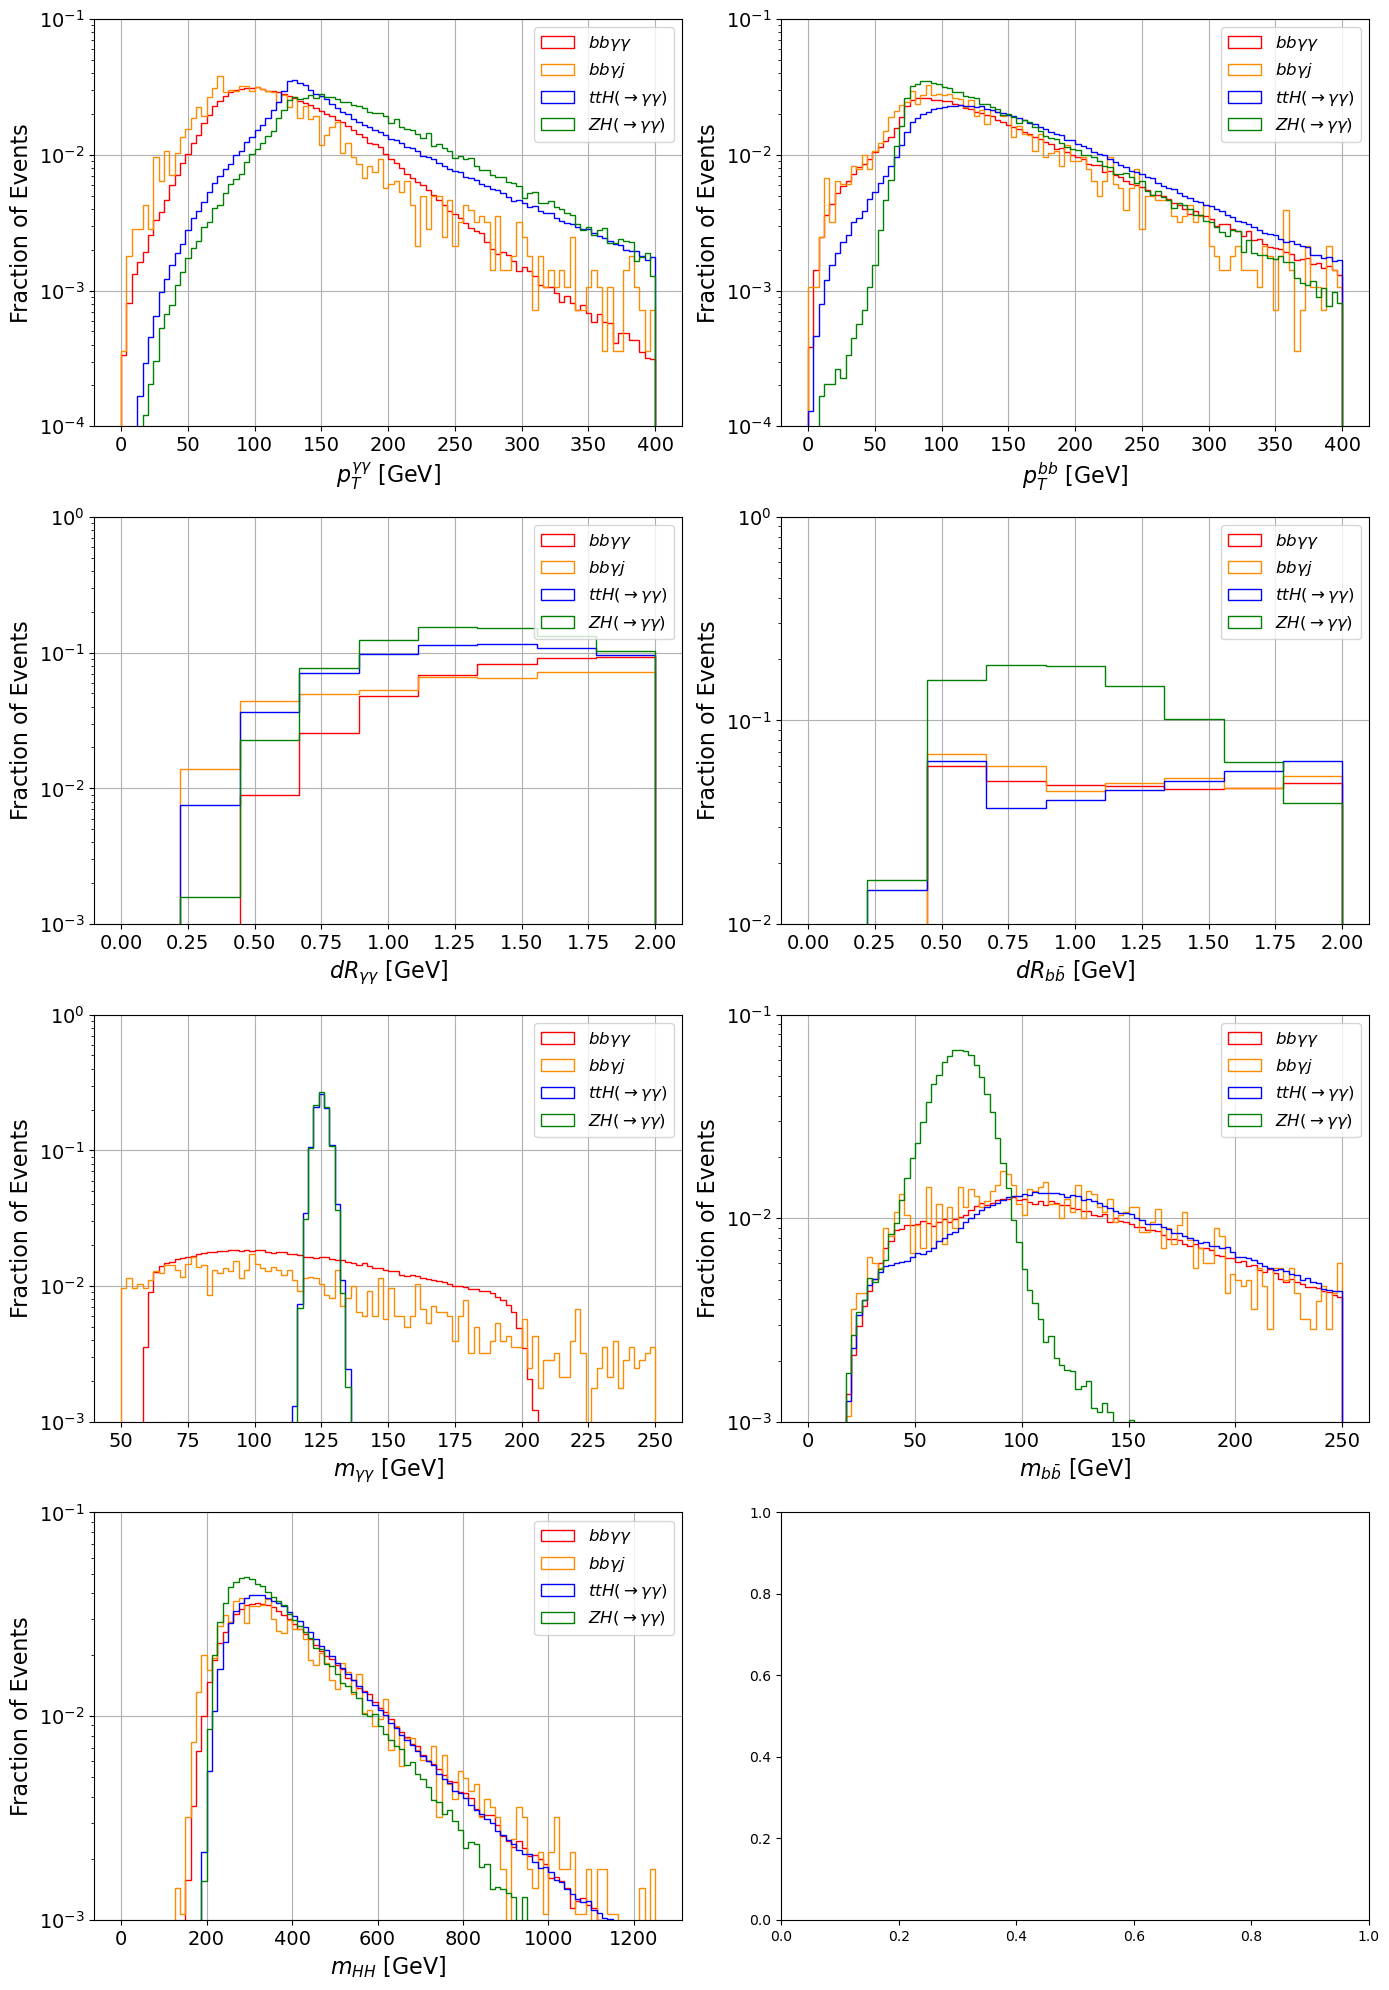

In [238]:

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()


# pT_pp
ax = axes[0]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_pho1_pho2_bbaa)/float(len(pT_pho1_pho2_bbaa))
ax.hist(pT_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_pho1_pho2_bbaj)/float(len(pT_pho1_pho2_bbaj))
ax.hist(pT_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_pho1_pho2_tth)/float(len(pT_pho1_pho2_tth))
ax.hist(pT_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_pho1_pho2_zh)/float(len(pT_pho1_pho2_zh))
ax.hist(pT_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# pT_bb
ax = axes[1]
Nbins= 100
rang = [0,400]

weights = np.ones_like(pT_b1_b2_bbaa)/float(len(pT_b1_b2_bbaa))
ax.hist(pT_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(pT_b1_b2_bbaj)/float(len(pT_b1_b2_bbaj))
ax.hist(pT_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(pT_b1_b2_tth)/float(len(pT_b1_b2_tth))
ax.hist(pT_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(pT_b1_b2_zh)/float(len(pT_b1_b2_zh))
ax.hist(pT_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-4,0.1)
ax.set_xlabel("$p_T^{bb}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_pp
ax = axes[2]
Nbins= 9
rang = [0.4,2]

weights = np.ones_like(dR_pho1_pho2_bbaa)/float(len(dR_pho1_pho2_bbaa))
ax.hist(dR_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_pho1_pho2_bbaj)/float(len(dR_pho1_pho2_bbaj))
ax.hist(dR_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_pho1_pho2_tth)/float(len(dR_pho1_pho2_tth))
ax.hist(dR_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_pho1_pho2_zh)/float(len(dR_pho1_pho2_zh))
ax.hist(dR_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("$dR_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# dR_bb
ax = axes[3]
Nbins= 9
rang = [0.4,2]

weights = np.ones_like(dR_b1_b2_bbaa)/float(len(dR_b1_b2_bbaa))
ax.hist(dR_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(dR_b1_b2_bbaj)/float(len(dR_b1_b2_bbaj))
ax.hist(dR_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(dR_b1_b2_tth)/float(len(dR_b1_b2_tth))
ax.hist(dR_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(dR_b1_b2_zh)/float(len(dR_b1_b2_zh))
ax.hist(dR_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-2,1)
ax.set_xlabel(r"$dR_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)




# m_pp
ax = axes[4]
Nbins= 100
rang = [50,250]

weights = np.ones_like(m_pho1_pho2_bbaa)/float(len(m_pho1_pho2_bbaa))
ax.hist(m_pho1_pho2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_pho1_pho2_bbaj)/float(len(m_pho1_pho2_bbaj))
ax.hist(m_pho1_pho2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_pho1_pho2_tth)/float(len(m_pho1_pho2_tth))
ax.hist(m_pho1_pho2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_pho1_pho2_zh)/float(len(m_pho1_pho2_zh))
ax.hist(m_pho1_pho2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,1)
ax.set_xlabel("$m_{\gamma\gamma}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_bb
ax = axes[5]
Nbins= 100
rang = [0,250]

weights = np.ones_like(m_b1_b2_bbaa)/float(len(m_b1_b2_bbaa))
ax.hist(m_b1_b2_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_b1_b2_bbaj)/float(len(m_b1_b2_bbaj))
ax.hist(m_b1_b2_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_b1_b2_tth)/float(len(m_b1_b2_tth))
ax.hist(m_b1_b2_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_b1_b2_zh)/float(len(m_b1_b2_zh))
ax.hist(m_b1_b2_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel(r"$m_{b\bar{b}}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)



# m_HH
ax = axes[6]
Nbins= 100
rang = [0,1250]

weights = np.ones_like(m_HH_bbaa)/float(len(m_HH_bbaa))
ax.hist(m_HH_bbaa, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='red', histtype='step', label="$bb\gamma\gamma$")
weights = np.ones_like(m_HH_bbaj)/float(len(m_HH_bbaj))
ax.hist(m_HH_bbaj, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='darkorange', histtype='step', label="$bb \gamma j$")
weights = np.ones_like(m_HH_tth)/float(len(m_HH_tth))
ax.hist(m_HH_tth, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='blue', histtype='step', label=r"$ttH(\rightarrow\gamma\gamma)$")
weights = np.ones_like(m_HH_zh)/float(len(m_HH_zh))
ax.hist(m_HH_zh, weights=weights, bins=Nbins, range=rang, lw=2, edgecolor='green', histtype='step', label=r"$ZH(\rightarrow\gamma\gamma)$")

ax.grid()  # Add grid lines
# ax.set_title(title,fontsize=14)
ax.set_ylim(1e-3,0.1)
ax.set_xlabel("$m_{HH}$ [GeV]",fontsize=16)
ax.set_ylabel("Fraction of Events",fontsize=16)
ax.tick_params(labelsize=14)
#plt.xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right',fontsize=12)


plt.tight_layout()
plt.show()

#  ALL CUTS (https://cds.cern.ch/record/2243387/files/ATL-PHYS-PUB-2017-001.pdf)

In [18]:
import itertools

MH = 125.0

# TRY ALL POSSIBLE COMBINATIONS ADN KEEP THE ONE THAT IS CLOSEST TO THE HIGGS MASS
def best_pair_mass(particles):
    """
    particles: array (N,3) with [pt, eta, phi]
    returns: indices (i,j), mass
    """
    best = None
    best_dm = 1e9

    for i, j in itertools.combinations(range(len(particles)), 2):
        m = inv_mass(particles[i:i+1], particles[j:j+1])[0]
        dm = abs(m - MH)
        if dm < best_dm:
            best_dm = dm
            best = (i, j, m)

    return best  # (i, j, m)



def pass_HH_extra_cuts(photons, bjets, jets):
    """
    photons, bjets, jets: arrays with [pt, eta, phi]
    """

    # --- need at least 2 and 2 ---
    if len(photons) < 2 or len(bjets) < 2:
        return False, None, None, None, None

    # --- choose best Higgs candidates ---
    ip, jp, m_phopho = best_pair_mass(photons)
    ib, jb, m_bb = best_pair_mass(bjets)

    pho1, pho2 = photons[ip], photons[jp]
    b1, b2 = bjets[ib], bjets[jb]

    # --- mass windows ---
    if not (122 < m_phopho < 128):
        return False, None, None, None, None
    if not (100 < m_bb < 150):
        return False, None, None, None, None

    # --- ΔR cuts ---
    if not (0.4 < delta_R(pho1[None,:], pho2[None,:])[0] < 2.0):
        return False, None, None, None, None
    if not (0.4 < delta_R(b1[None,:], b2[None,:])[0] < 2.0):
        return False, None, None, None, None

    # --- pT of Higgs candidates ---
    if pT12(pho1[None,:], pho2[None,:])[0] < 80:
        return False, None, None, None, None
    if pT12(b1[None,:], b2[None,:])[0] < 80:
        return False, None, None, None, None

    # --- ΔR(γ, j) isolation ---
    for phot in [pho1, pho2]:
        for j in jets:
            if delta_R(phot[None,:], j[None,:])[0] < 0.4:
                return False, None, None, None, None

    return True, ip, jp, ib, jb

#### Signal point-1

In [19]:
filename = "../DATA/signal/point1.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_S1 = []
pho_sumpt_S1 = []

jet_n_S1 = []
jet_sumpt_S1 = []

b_n_S1 = []
b_sumpt_S1 = []


pho1_S1 = []
pho2_S1 = []

b1_S1 = []
b2_S1 = []

MET_S1 = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_S1.append( len(photon_pt[iev]) )
        pho_sumpt_S1.append( sum(photon_pt[iev]) ) 

        jet_n_S1.append( len(jet_pt[iev]) )
        jet_sumpt_S1.append( sum(jet_pt[iev]) ) 

        b_n_S1.append( len(btag_pt[iev]) )
        b_sumpt_S1.append( sum(btag_pt[iev]) ) 

        
        pho1_S1.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_S1.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_S1.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_S1.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_S1.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_S1 = np.asarray(pho_n_S1)
pho_sumpt_S1 = np.asarray(pho_sumpt_S1)

jet_n_S1 = np.asarray(jet_n_S1)
jet_sumpt_S1 = np.asarray(jet_sumpt_S1)

b_n_S1 = np.asarray(b_n_S1)
b_sumpt_S1 = np.asarray(b_sumpt_S1)


pho1_S1 = np.asarray(pho1_S1)
pho2_S1 = np.asarray(pho2_S1)

b1_S1 = np.asarray(b1_S1)
b2_S1 = np.asarray(b2_S1)

MET_S1 = np.asarray(MET_S1)




print(" pho1_S1.shape: ", pho1_S1.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_S1)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (191677,)
 pho1_S1.shape:  (42762, 3)


In [20]:
initial_evs = 191677
events_ok = 42762

cross_basic_cuts_fb = 0.02659216426864612 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.005932553871647852 [fb]
Events expected:  17.797661614943557     for L= 3000  [fb-1]


#### bbaa

In [8]:
filename = "../DATA/backgrounds/bbaa.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaa = []
pho_sumpt_bbaa = []

jet_n_bbaa = []
jet_sumpt_bbaa = []

b_n_bbaa = []
b_sumpt_bbaa = []


pho1_bbaa = []
pho2_bbaa = []

b1_bbaa = []
b2_bbaa = []

MET_bbaa = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaa.append( len(photon_pt[iev]) )
        pho_sumpt_bbaa.append( sum(photon_pt[iev]) ) 

        jet_n_bbaa.append( len(jet_pt[iev]) )
        jet_sumpt_bbaa.append( sum(jet_pt[iev]) ) 

        b_n_bbaa.append( len(btag_pt[iev]) )
        b_sumpt_bbaa.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaa.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaa.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaa.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaa.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaa.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaa = np.asarray(pho_n_bbaa)
pho_sumpt_bbaa = np.asarray(pho_sumpt_bbaa)

jet_n_bbaa = np.asarray(jet_n_bbaa)
jet_sumpt_bbaa = np.asarray(jet_sumpt_bbaa)

b_n_bbaa = np.asarray(b_n_bbaa)
b_sumpt_bbaa = np.asarray(b_sumpt_bbaa)


pho1_bbaa = np.asarray(pho1_bbaa)
pho2_bbaa = np.asarray(pho2_bbaa)

b1_bbaa = np.asarray(b1_bbaa)
b2_bbaa = np.asarray(b2_bbaa)

MET_bbaa = np.asarray(MET_bbaa)




print(" pho1_bbaa.shape: ", pho1_bbaa.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)


# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (380952,)
 pho1_bbaa.shape:  (703, 3)


In [9]:
initial_evs = 380952
events_ok = 703

cross_basic_cuts_fb = 2.171428463266681 # fb

In [10]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.0040071038075045595 [fb]
Events expected:  12.021311422513678     for L= 3000  [fb-1]


#### bbaj (NO FAKES)

In [11]:
filename = "../DATA/backgrounds/bbaj_noFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj_noFAKES = []
pho_sumpt_bbaj_noFAKES = []

jet_n_bbaj_noFAKES = []
jet_sumpt_bbaj_noFAKES = []

b_n_bbaj_noFAKES = []
b_sumpt_bbaj_noFAKES = []


pho1_bbaj_noFAKES = []
pho2_bbaj_noFAKES = []

b1_bbaj_noFAKES = []
b2_bbaj_noFAKES = []

MET_bbaj_noFAKES = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj_noFAKES.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj_noFAKES.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj_noFAKES.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj_noFAKES.append( sum(jet_pt[iev]) ) 

        b_n_bbaj_noFAKES.append( len(btag_pt[iev]) )
        b_sumpt_bbaj_noFAKES.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj_noFAKES.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj_noFAKES.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj_noFAKES.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj_noFAKES.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj_noFAKES.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaj_noFAKES = np.asarray(pho_n_bbaj_noFAKES)
pho_sumpt_bbaj_noFAKES = np.asarray(pho_sumpt_bbaj_noFAKES)

jet_n_bbaj_noFAKES = np.asarray(jet_n_bbaj_noFAKES)
jet_sumpt_bbaj_noFAKES = np.asarray(jet_sumpt_bbaj_noFAKES)

b_n_bbaj_noFAKES = np.asarray(b_n_bbaj_noFAKES)
b_sumpt_bbaj_noFAKES = np.asarray(b_sumpt_bbaj_noFAKES)


pho1_bbaj_noFAKES = np.asarray(pho1_bbaj_noFAKES)
pho2_bbaj_noFAKES = np.asarray(pho2_bbaj_noFAKES)

b1_bbaj_noFAKES = np.asarray(b1_bbaj_noFAKES)
b2_bbaj_noFAKES = np.asarray(b2_bbaj_noFAKES)

MET_bbaj_noFAKES = np.asarray(MET_bbaj_noFAKES)


print(" pho1_bbaj_noFAKES.shape: ", pho1_bbaj_noFAKES.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2428,)
 pho1_bbaj_noFAKES.shape:  (1, 3)


In [12]:
initial_evs = 2428
events_ok = 1

cross_basic_cuts_fb = 16.790270624904363 # fb

In [13]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.006915267967423543 [fb]
Events expected:  20.74580390227063     for L= 3000  [fb-1]


#### bbaj (with FAKES)

In [14]:
filename = "../DATA/backgrounds/bbaj_wFAKES.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_bbaj = []
pho_sumpt_bbaj = []

jet_n_bbaj = []
jet_sumpt_bbaj = []

b_n_bbaj = []
b_sumpt_bbaj = []


pho1_bbaj = []
pho2_bbaj = []

b1_bbaj = []
b2_bbaj = []

MET_bbaj = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_bbaj.append( len(photon_pt[iev]) )
        pho_sumpt_bbaj.append( sum(photon_pt[iev]) ) 

        jet_n_bbaj.append( len(jet_pt[iev]) )
        jet_sumpt_bbaj.append( sum(jet_pt[iev]) ) 

        b_n_bbaj.append( len(btag_pt[iev]) )
        b_sumpt_bbaj.append( sum(btag_pt[iev]) ) 

        
        pho1_bbaj.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_bbaj.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_bbaj.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_bbaj.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_bbaj.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_bbaj = np.asarray(pho_n_bbaj)
pho_sumpt_bbaj = np.asarray(pho_sumpt_bbaj)

jet_n_bbaj = np.asarray(jet_n_bbaj)
jet_sumpt_bbaj = np.asarray(jet_sumpt_bbaj)

b_n_bbaj = np.asarray(b_n_bbaj)
b_sumpt_bbaj = np.asarray(b_sumpt_bbaj)


pho1_bbaj = np.asarray(pho1_bbaj)
pho2_bbaj = np.asarray(pho2_bbaj)

b1_bbaj = np.asarray(b1_bbaj)
b2_bbaj = np.asarray(b2_bbaj)

MET_bbaj = np.asarray(MET_bbaj)


print(" pho1_bbaj.shape: ", pho1_bbaj.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (2802,)
 pho1_bbaj.shape:  (2, 3)


In [15]:
initial_evs = 2802
events_ok = 2

cross_basic_cuts_fb = 19.386077717379234 # fb

In [16]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.013837314573432714 [fb]
Events expected:  41.51194372029814     for L= 3000  [fb-1]


In [17]:
cross_basic_cuts_fb = 2.5236714365053565 # fb

In [18]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.001801335786227949 [fb]
Events expected:  5.404007358683847     for L= 3000  [fb-1]


#### tth

In [19]:
filename = "../DATA/backgrounds/tth.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_tth = []
pho_sumpt_tth = []

jet_n_tth = []
jet_sumpt_tth = []

b_n_tth = []
b_sumpt_tth = []


pho1_tth = []
pho2_tth = []

b1_tth = []
b2_tth = []

MET_tth = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_tth.append( len(photon_pt[iev]) )
        pho_sumpt_tth.append( sum(photon_pt[iev]) ) 

        jet_n_tth.append( len(jet_pt[iev]) )
        jet_sumpt_tth.append( sum(jet_pt[iev]) ) 

        b_n_tth.append( len(btag_pt[iev]) )
        b_sumpt_tth.append( sum(btag_pt[iev]) ) 

        
        pho1_tth.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_tth.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_tth.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_tth.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_tth.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_tth = np.asarray(pho_n_tth)
pho_sumpt_tth = np.asarray(pho_sumpt_tth)

jet_n_tth = np.asarray(jet_n_tth)
jet_sumpt_tth = np.asarray(jet_sumpt_tth)

b_n_tth = np.asarray(b_n_tth)
b_sumpt_tth = np.asarray(b_sumpt_tth)


pho1_tth = np.asarray(pho1_tth)
pho2_tth = np.asarray(pho2_tth)

b1_tth = np.asarray(b1_tth)
b2_tth = np.asarray(b2_tth)

MET_tth = np.asarray(MET_tth)


print(" pho1_tth.shape: ", pho1_tth.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (606082,)
 pho1_tth.shape:  (35350, 3)


In [20]:
initial_evs = 606082
events_ok = 35350

cross_basic_cuts_fb = 0.033768365117857184 # fb

In [21]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  0.001969554791127688 [fb]
Events expected:  5.908664373383065     for L= 3000  [fb-1]


#### zh

In [22]:
filename = "../DATA/backgrounds/zh.h5"

with h5py.File(filename, "r") as f:

    # ARRAYS
    photon_pt = f["photon_pt"][:]
    photon_phi = f["photon_phi"][:]
    photon_eta = f["photon_eta"][:]

    jet_pt = f["jet_pt"][:]
    jet_phi = f["jet_phi"][:]
    jet_eta = f["jet_eta"][:]

    btag_pt = f["btag_pt"][:]
    btag_phi = f["btag_phi"][:]
    btag_eta = f["btag_eta"][:]

    MET_pt = f["MET_pt"][:]
    MET_phi = f["MET_phi"][:]

    print("Let's see the data and shape:")
    

    print(" photon_pt.shape: ", photon_pt.shape)


# to save after cuts
pho_n_zh = []
pho_sumpt_zh = []

jet_n_zh = []
jet_sumpt_zh = []

b_n_zh = []
b_sumpt_zh = []


pho1_zh = []
pho2_zh = []

b1_zh = []
b2_zh = []

MET_zh = []

for iev in range(0, len(photon_pt)):

    # DEFINE THE PARTICLES
    photons_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(photon_pt[iev], photon_eta[iev], photon_phi[iev]) ])
    
    bs_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(btag_pt[iev], btag_eta[iev], btag_phi[iev]) ])
    
    jets_iev = np.array([ [pt, eta, phi] for pt, eta, phi in zip(jet_pt[iev], jet_eta[iev], jet_phi[iev]) ])

    
    # APPLY NEW CUTS
    PASS, pho1_it, pho2_it, b1_it, b2_it = pass_HH_extra_cuts( photons=photons_iev, bjets=bs_iev, jets=jets_iev )


    # IF THE EVENT PASSES THE NEW CUTS SAVE IT
    if PASS:

        pho_n_zh.append( len(photon_pt[iev]) )
        pho_sumpt_zh.append( sum(photon_pt[iev]) ) 

        jet_n_zh.append( len(jet_pt[iev]) )
        jet_sumpt_zh.append( sum(jet_pt[iev]) ) 

        b_n_zh.append( len(btag_pt[iev]) )
        b_sumpt_zh.append( sum(btag_pt[iev]) ) 

        
        pho1_zh.append( [photon_pt[iev][pho1_it], photon_eta[iev][pho1_it], photon_phi[iev][pho1_it]] )
        pho2_zh.append( [photon_pt[iev][pho2_it], photon_eta[iev][pho2_it], photon_phi[iev][pho2_it]] )
        
        b1_zh.append( [btag_pt[iev][b1_it], btag_eta[iev][b1_it], btag_phi[iev][b1_it]] )
        b2_zh.append( [btag_pt[iev][b2_it], btag_eta[iev][b2_it], btag_phi[iev][b2_it]] )
        
        MET_zh.append( [MET_pt[iev][0], MET_phi[iev][0]] )


# CONVERT INTO ARRAYS
pho_n_zh = np.asarray(pho_n_zh)
pho_sumpt_zh = np.asarray(pho_sumpt_zh)

jet_n_zh = np.asarray(jet_n_zh)
jet_sumpt_zh = np.asarray(jet_sumpt_zh)

b_n_zh = np.asarray(b_n_zh)
b_sumpt_zh = np.asarray(b_sumpt_zh)


pho1_zh = np.asarray(pho1_zh)
pho2_zh = np.asarray(pho2_zh)

b1_zh = np.asarray(b1_zh)
b2_zh = np.asarray(b2_zh)

MET_zh = np.asarray(MET_zh)


print(" pho1_zh.shape: ", pho1_zh.shape)
initial_evs = len(photon_pt)
events_ok = len(pho1_bbaa)



# delete
del photon_pt
del photon_eta
del photon_phi

del jet_pt
del jet_eta
del jet_phi

del btag_pt
del btag_eta
del btag_phi

del MET_pt
del MET_phi

Let's see the data and shape:
 photon_pt.shape:  (83047,)
 pho1_zh.shape:  (1046, 3)


In [23]:
initial_evs = 83047
events_ok = 1046

cross_basic_cuts_fb = 0.006521839124728637 # fb

In [24]:

aceptancia = 1.*events_ok/initial_evs
luminosity= 3000

fid_cross = cross_basic_cuts_fb * aceptancia
Tot_ev_expected = cross_basic_cuts_fb * aceptancia * luminosity

print('Fiducial cross section: ', fid_cross, "[fb]")
print('Events expected: ', Tot_ev_expected, "    for L=", luminosity, " [fb-1]")

Fiducial cross section:  8.214437275839169e-05 [fb]
Events expected:  0.24643311827517508     for L= 3000  [fb-1]
